# Data Loading and Mapping

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier, XGBRegressor

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [2]:
df = pd.read_csv('filtered_data.csv')

In [3]:
df.head()

,_BMI5,_BMI5CAT,_AGE_G,_AGE80,_AGE65YR,_INCOMG1,INCOME3,_SMOKER3,_RFSMOK3,SMOKDAY2,...,MENTHLTH,ADDEPEV3,LANDSEX3,SEXVAR,DIABETE4,PERSDOC3,PRIMINS2,_URBSTAT,_IMPRACE,CHILDREN
0,2249.0,2.0,6.0,78.0,2.0,9.0,99.0,4.0,1.0,NaN,...,88.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,1.0,88.0
1,2583.0,3.0,6.0,80.0,2.0,7.0,11.0,3.0,1.0,3.0,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
2,2253.0,2.0,5.0,59.0,1.0,9.0,99.0,1.0,2.0,1.0,...,88.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,1.0,88.0
3,2509.0,3.0,6.0,80.0,2.0,4.0,6.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
4,1977.0,2.0,4.0,47.0,1.0,2.0,3.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,5.0,1.0,1.0,88.0


In [4]:
df.columns

Index(['_BMI5', '_BMI5CAT', '_AGE_G', '_AGE80', '_AGE65YR', '_INCOMG1',
       'INCOME3', '_SMOKER3', '_RFSMOK3', 'SMOKDAY2', 'CVDINFR4', 'CVDCRHD4',
       'ASTHMA3', '_LTASTH1', 'CHCKDNY2', 'MARITAL', 'EDUCA', '_EDUCAG',
       'GENHLTH', 'EXERANY2', '_TOTINDA', 'HAVARTH4', '_DRDXAR2', 'MENTHLTH',
       'ADDEPEV3', 'LANDSEX3', 'SEXVAR', 'DIABETE4', 'PERSDOC3', 'PRIMINS2',
       '_URBSTAT', '_IMPRACE', 'CHILDREN'],
      dtype='str')

In [5]:
chosen_columns = ['_BMI5', '_AGE_G', 'INCOME3', '_SMOKER3', 'CVDINFR4', 'CVDCRHD4', 
                 'ASTHMA3', 'CHCKDNY2', 'MARITAL', 'EDUCA', 'GENHLTH', 'EXERANY2',
                 'HAVARTH4', 'MENTHLTH', 'ADDEPEV3', 'SEXVAR', 'PERSDOC3', 'PRIMINS2',
                 '_URBSTAT', 'CHILDREN', 'DIABETE4']

df_eda = df[chosen_columns]

In [6]:
df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,2249.0,6.0,99.0,4.0,2.0,2.0,2.0,2.0,3.0,4.0,...,1.0,1.0,88.0,2.0,2.0,2.0,3.0,1.0,88.0,3.0
1,2583.0,6.0,11.0,3.0,2.0,1.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
2,2253.0,5.0,99.0,1.0,2.0,2.0,2.0,2.0,6.0,5.0,...,1.0,1.0,88.0,2.0,1.0,3.0,1.0,1.0,88.0,3.0
3,2509.0,6.0,6.0,4.0,2.0,2.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
4,1977.0,4.0,3.0,4.0,2.0,2.0,2.0,2.0,5.0,5.0,...,2.0,2.0,88.0,2.0,1.0,1.0,5.0,1.0,88.0,3.0


In [7]:
column_mapper = {
    'DIABETE4': {
        1: 'Yes',
        2: np.nan,
        3: 'No',
        4: 'Yes',
        7: np.nan,
        9: np.nan
    },
    '_AGE_G': {
        1: '18-24',
        2: '25-34',
        3: '35-44',
        4: '45-54',
        5: '55-64',
        6: '65+'
    },
    'INCOME3': {
        1: '< \$10k', 
        2: '\$10k - \$15k', 
        3: '\$15k - \$20k', 
        4: '\$20k - \$25k', 
        5: '\$25k - \$35k', 
        6: '\$35k - \$50k', 
        7: '\$50k - \$75k', 
        8: '\$75k - \$100k', 
        9: '\$100k - \$150k', 
        10: '\$150k - \$200k', 
        11: '>= \$200k', 
        77: 'Not Sure', 
        99: 'Refused'
    },
    '_SMOKER3': {
        1: 'Current smoker - every day',
        2: 'Current smoker - some days',
        3: 'Former smoker',
        4: 'Never smoked',
        9: 'Don’t know/Refused'
    },
    'GENHLTH': {
        1: 'Excellent',
        2: 'Very good',
        3: 'Good',
        4: 'Fair',
        5: 'Poor',
        7: 'Don’t know/Not Sure',
        9: 'Refused'
    },
    'EDUCA': {
        1: 'Never attended/Kindergarten',
        2: 'Elementary',
        3: 'Some high school',
        4: 'High school graduate',
        5: 'Some college/Technical school',
        6: 'College graduate',
        9: 'Refused'
    },
    'MARITAL': {
        1: 'Married',
        2: 'Divorced',
        3: 'Widowed',
        4: 'Separated',
        5: 'Never married',
        6: 'Member of unmarried couple',
        9: 'Refused'
    },
    'SEXVAR': {
        1: 'Male',
        2: 'Female'
    },
    'PERSDOC3': {
        1: 'Yes, only one',
        2: 'More than one',
        3: 'No',
        7: 'Don’t know/Not Sure',
        9: 'Refused'
    },
    'PRIMINS2': {
        1: 'Employer/Union plan',
        2: 'Private plan',
        3: 'Medicare',
        4: 'Medigap',
        5: 'Medicaid',
        6: 'CHIP',
        7: 'Military/VA',
        8: 'Indian Health Service',
        9: 'State sponsored plan',
        10: 'Other government program',
        88: 'No coverage',
        77: 'Don’t know',
        99: 'Refused'
    },
    '_URBSTAT': {
        1: 'Urban',
        2: 'Rural'
    },
    'EXERANY2': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CVDINFR4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CVDCRHD4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'ASTHMA3':  {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CHCKDNY2': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'HAVARTH4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'ADDEPEV3': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
}

for column in df_eda.columns:
    if column in column_mapper.keys():
        df_eda[column] = df_eda[column].map(column_mapper[column])

df_eda['_BMI5'] = df_eda['_BMI5'] / 100.0
df_eda['CHILDREN'] = df['CHILDREN'].replace({
    88: 0,
    99: 'Refused'
})
df_eda['MENTHLTH'] = df['MENTHLTH'].replace({
    88: 0,
    77: 'Don’t know', 
    99: 'Refused'
})

df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,22.49,65+,Refused,Never smoked,No,No,No,No,Widowed,High school graduate,...,Yes,Yes,0.0,No,Female,More than one,Medicare,Urban,0.0,No
1,25.83,65+,>= \$200k,Former smoker,No,Yes,No,No,Married,College graduate,...,Yes,Yes,0.0,No,Male,"Yes, only one",Medicare,Urban,0.0,No
2,22.53,55-64,Refused,Current smoker - every day,No,No,No,No,Member of unmarried couple,Some college/Technical school,...,Yes,Yes,0.0,No,Male,No,Employer/Union plan,Urban,0.0,No
3,25.09,65+,\$35k - \$50k,Never smoked,No,No,No,No,Married,College graduate,...,Yes,Yes,0.0,No,Male,"Yes, only one",Medicare,Urban,0.0,No
4,19.77,45-54,\$15k - \$20k,Never smoked,No,No,No,No,Never married,Some college/Technical school,...,No,No,0.0,No,Male,"Yes, only one",Medicaid,Urban,0.0,No


## EDA Setup

In [8]:
from pypalettes import load_cmap
%config InlineBackend.figure_format = 'retina'
from qbstyles import mpl_style

neon_cmap = load_cmap('Neon')
neon_colors = np.array(neon_cmap.colors)

blue_orange_cmap = load_cmap("Blue2DarkOrange12Steps")
blue_orange_colors = np.array(blue_orange_cmap.colors)

mpl_style(dark=True)

# Missing Values Analysis

Missing values analysis is very interesting here because we can treat 'Don't Know' or 'Refused' answer as missing values or treat them as a feature on their own. We must analyze whether these values happens completely randomly (MCAR), or does it has a unique pattern that we can study (either MAR or MNAR). If its the former then I think we can safely drop the data (assuming we still have some decent amount left), if its the latter then we can try imputing the missing data, either with mean or mode or even model-based imputation.

For analysis purpose I will be treating them as missing values first.

In [9]:
df_miss = df_eda.copy()

na_values = [
    'Refused',
    'Not Sure',
    'Don’t know',
    'Don’t know/Not Sure', 
    'Don’t know/Refused', 
]

df_miss = df_miss.replace(na_values, np.nan)

In [10]:
df_miss.shape

(457670, 21)

In [11]:
df_miss.isna().sum()

_BMI5       43037
_AGE_G          0
INCOME3     87423
_SMOKER3    32022
CVDINFR4     3115
CVDCRHD4     4578
ASTHMA3      1861
CHCKDNY2     1979
MARITAL      4222
EDUCA        2363
GENHLTH      1310
EXERANY2     1315
HAVARTH4     2573
MENTHLTH     8156
ADDEPEV3     2664
SEXVAR          0
PERSDOC3     4613
PRIMINS2    18544
_URBSTAT    14623
CHILDREN     9379
DIABETE4     4429
dtype: int64

Let's visualize them with a countplot for clearer insight.

/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/matplotlib_inline/config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):
/tmp/ipykernel_25794/1954858484.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_25794/1954858484.py:7: UserWarning: 
The palette list has fewer values (5) than needed (21) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


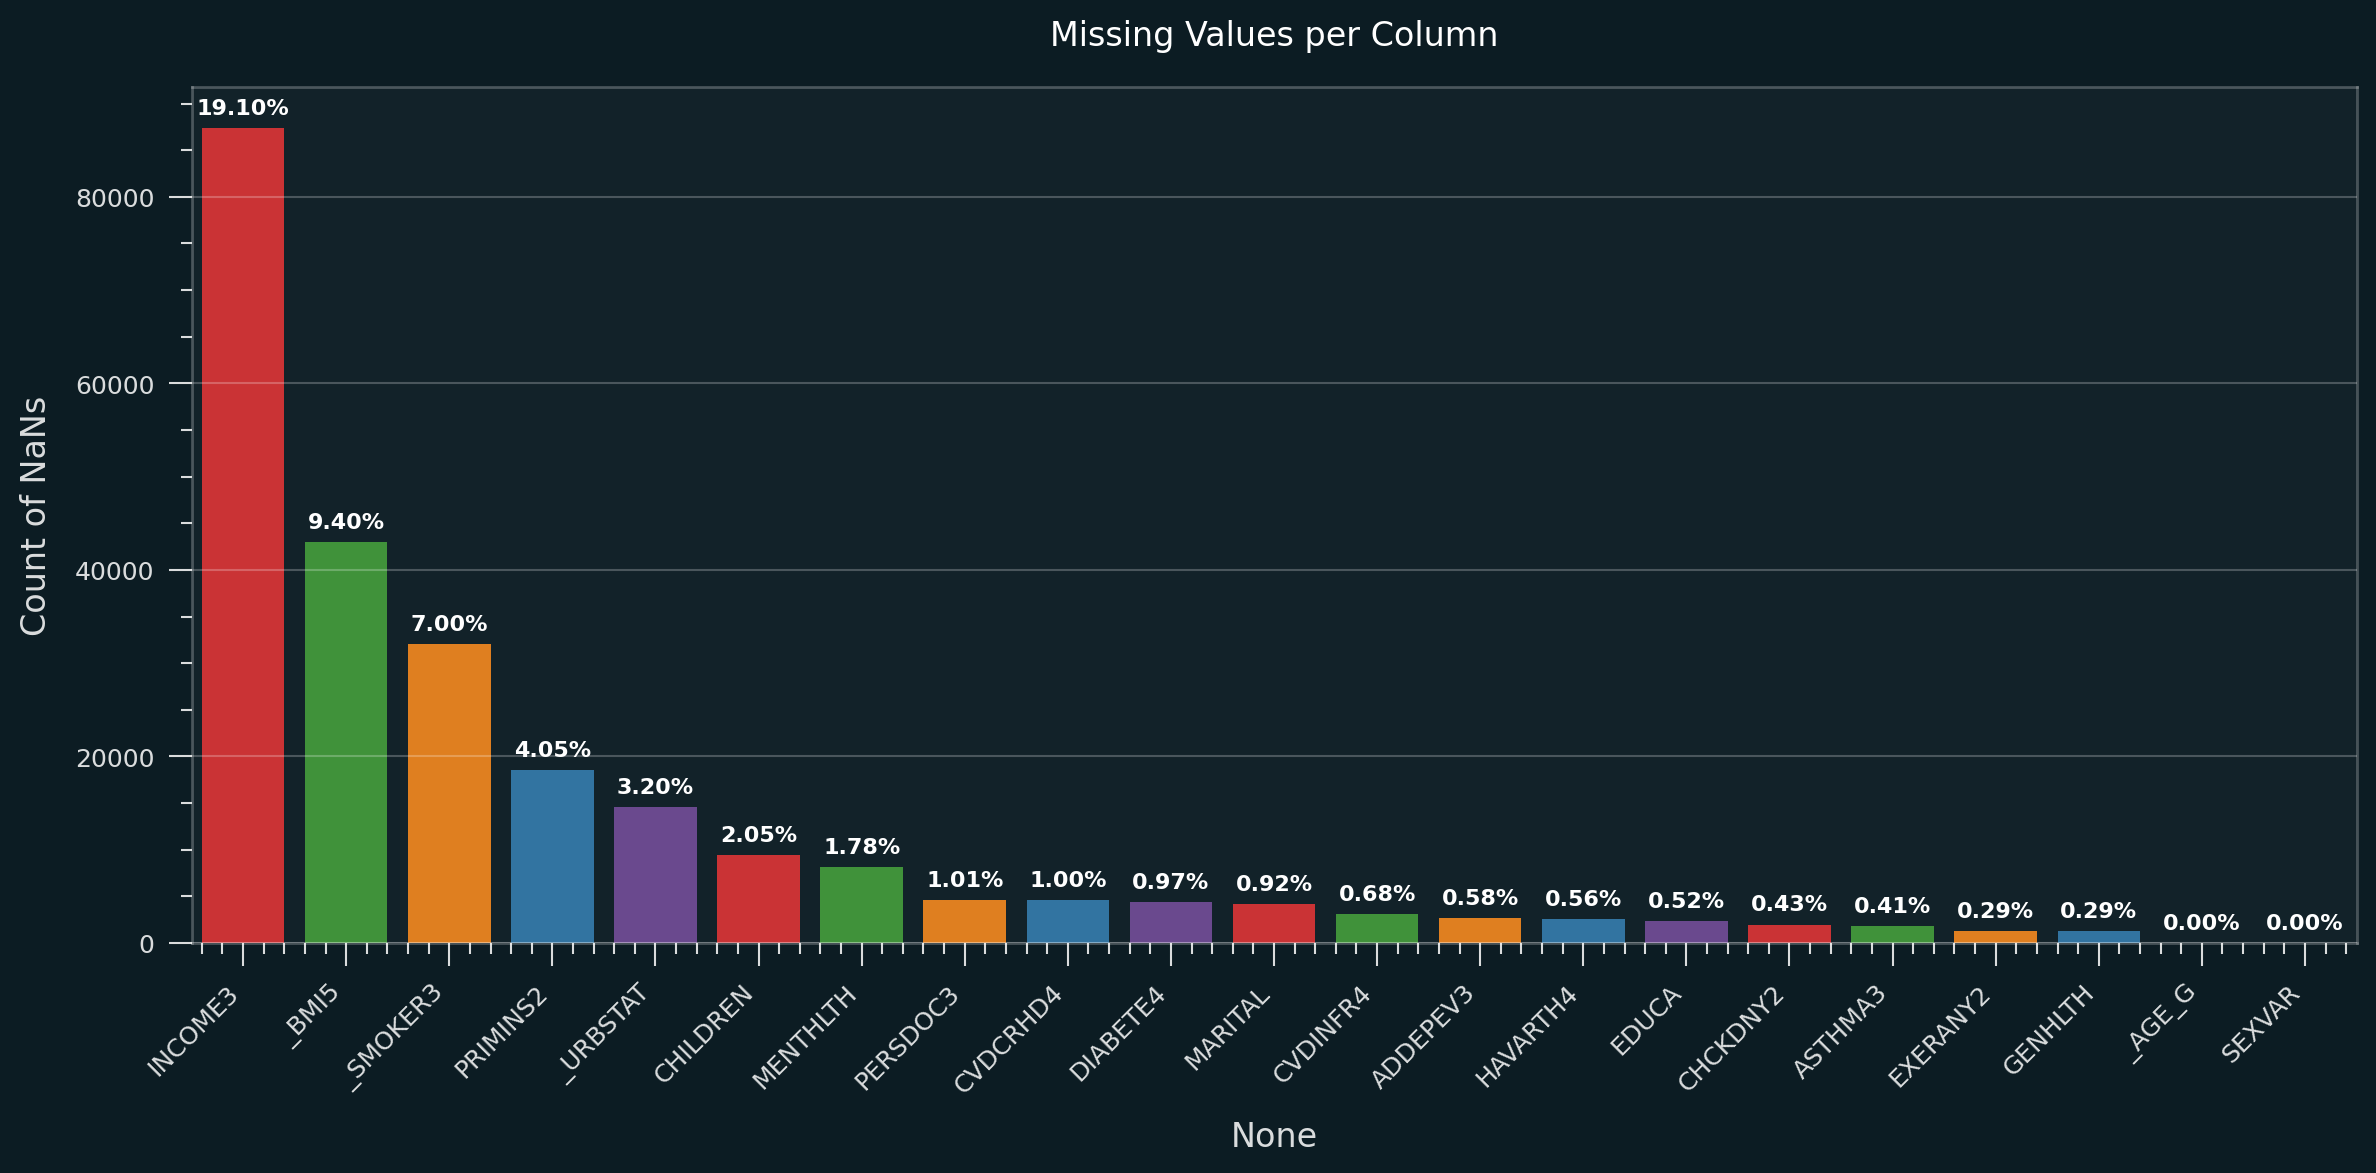

In [12]:
missing_counts = df_miss.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

ax = sns.barplot(
    x=missing_counts.index, 
    y=missing_counts.values, 
    palette=colors
)

plt.title('Missing Values per Column')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count of NaNs')

for p in ax.patches:
    percentage = (p.get_height() / len(df_miss)) * 100
    
    ax.annotate(f'{percentage:.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=8, fontweight='bold', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.savefig(f"./outputs/modelling/missing_values.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.tight_layout()
plt.show()

Well well well, this already denies the MCAR hypothesis because there are clearly some columsn that has way higher missing values than other. lets specifically look at the INCOME3 column. This column has 87k data missing out of 457k samples, that is nearly 20% of the data misisng, which can be pretty bad to lose. Since theres clearly a pattern already, mindlessly dropping the data should be saved for last option. We need to try to find a way to manipulate these missing data (either by imputing or just straight up keeping them as a 'unknown' value). Let's see if theres some unique pattern that we can immediately identify by checking the missingness with the missingno library.

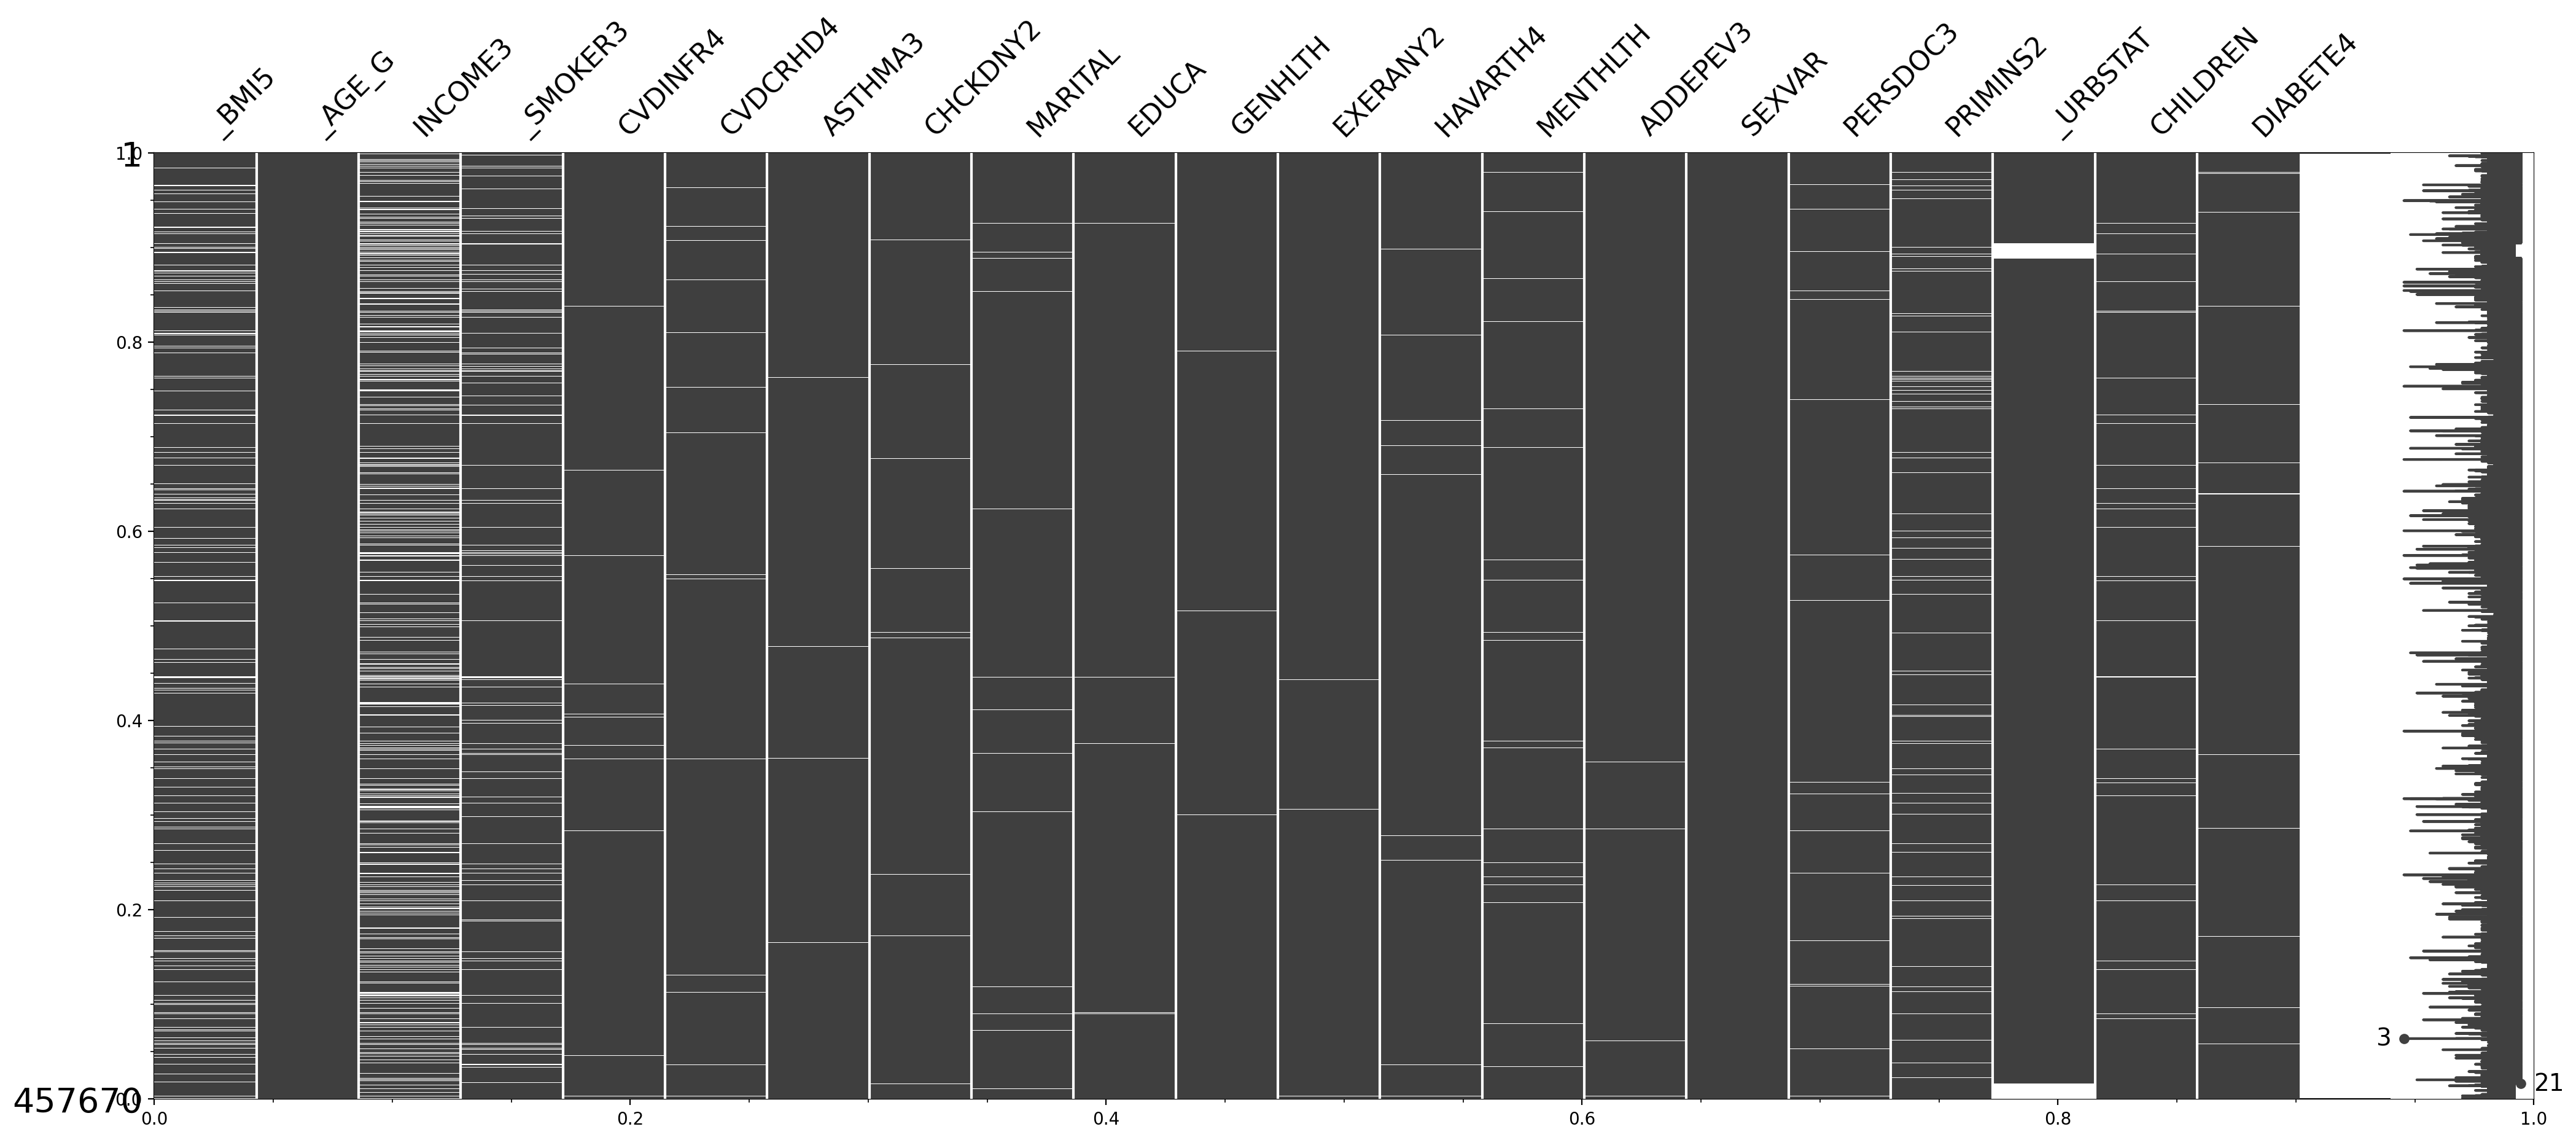

In [13]:
import missingno as msno

with plt.style.context('default'):
    msno.matrix(df_miss)

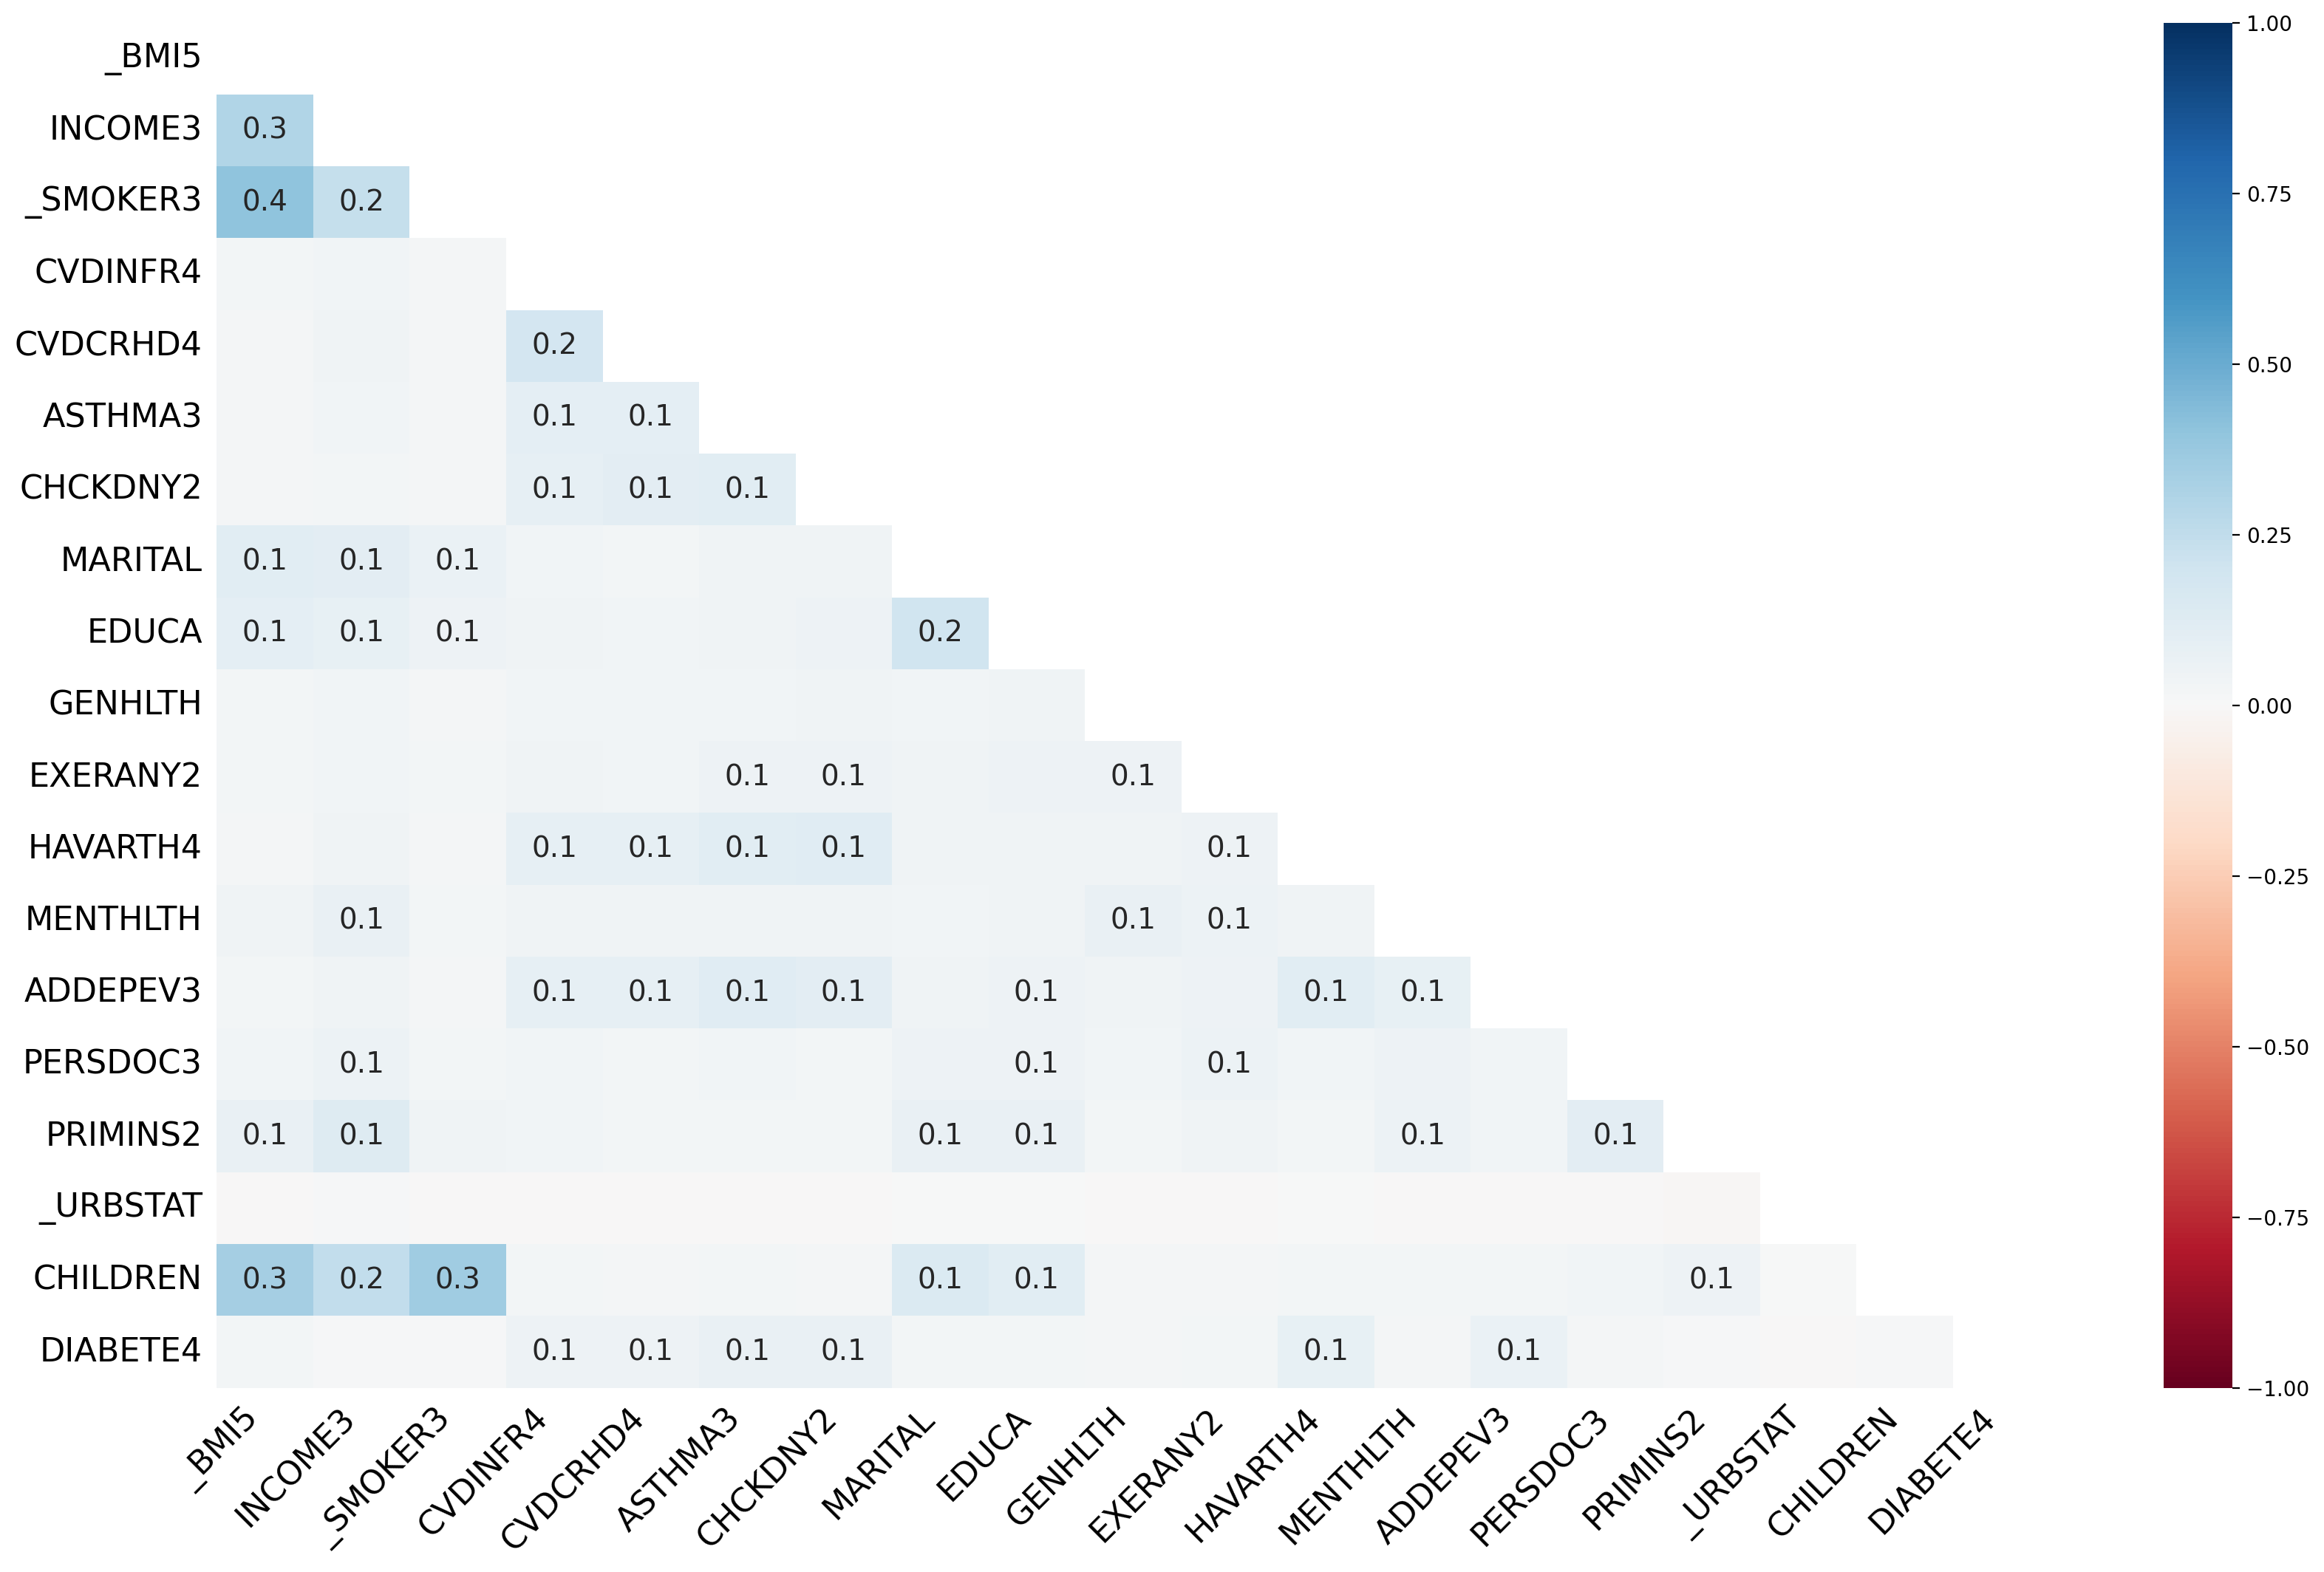

In [14]:
with plt.style.context('default'):
    msno.heatmap(df_miss)

An interesting result, there are some weak correlations between _BMI5, INCOME3, and _SMOKER3. Coincidentally, these 3 columns are also the columns that has a large amount of missing values (30k+), so this may have happened due to sample size sensitivity. Let's further check with dendograms to check these correlations further.

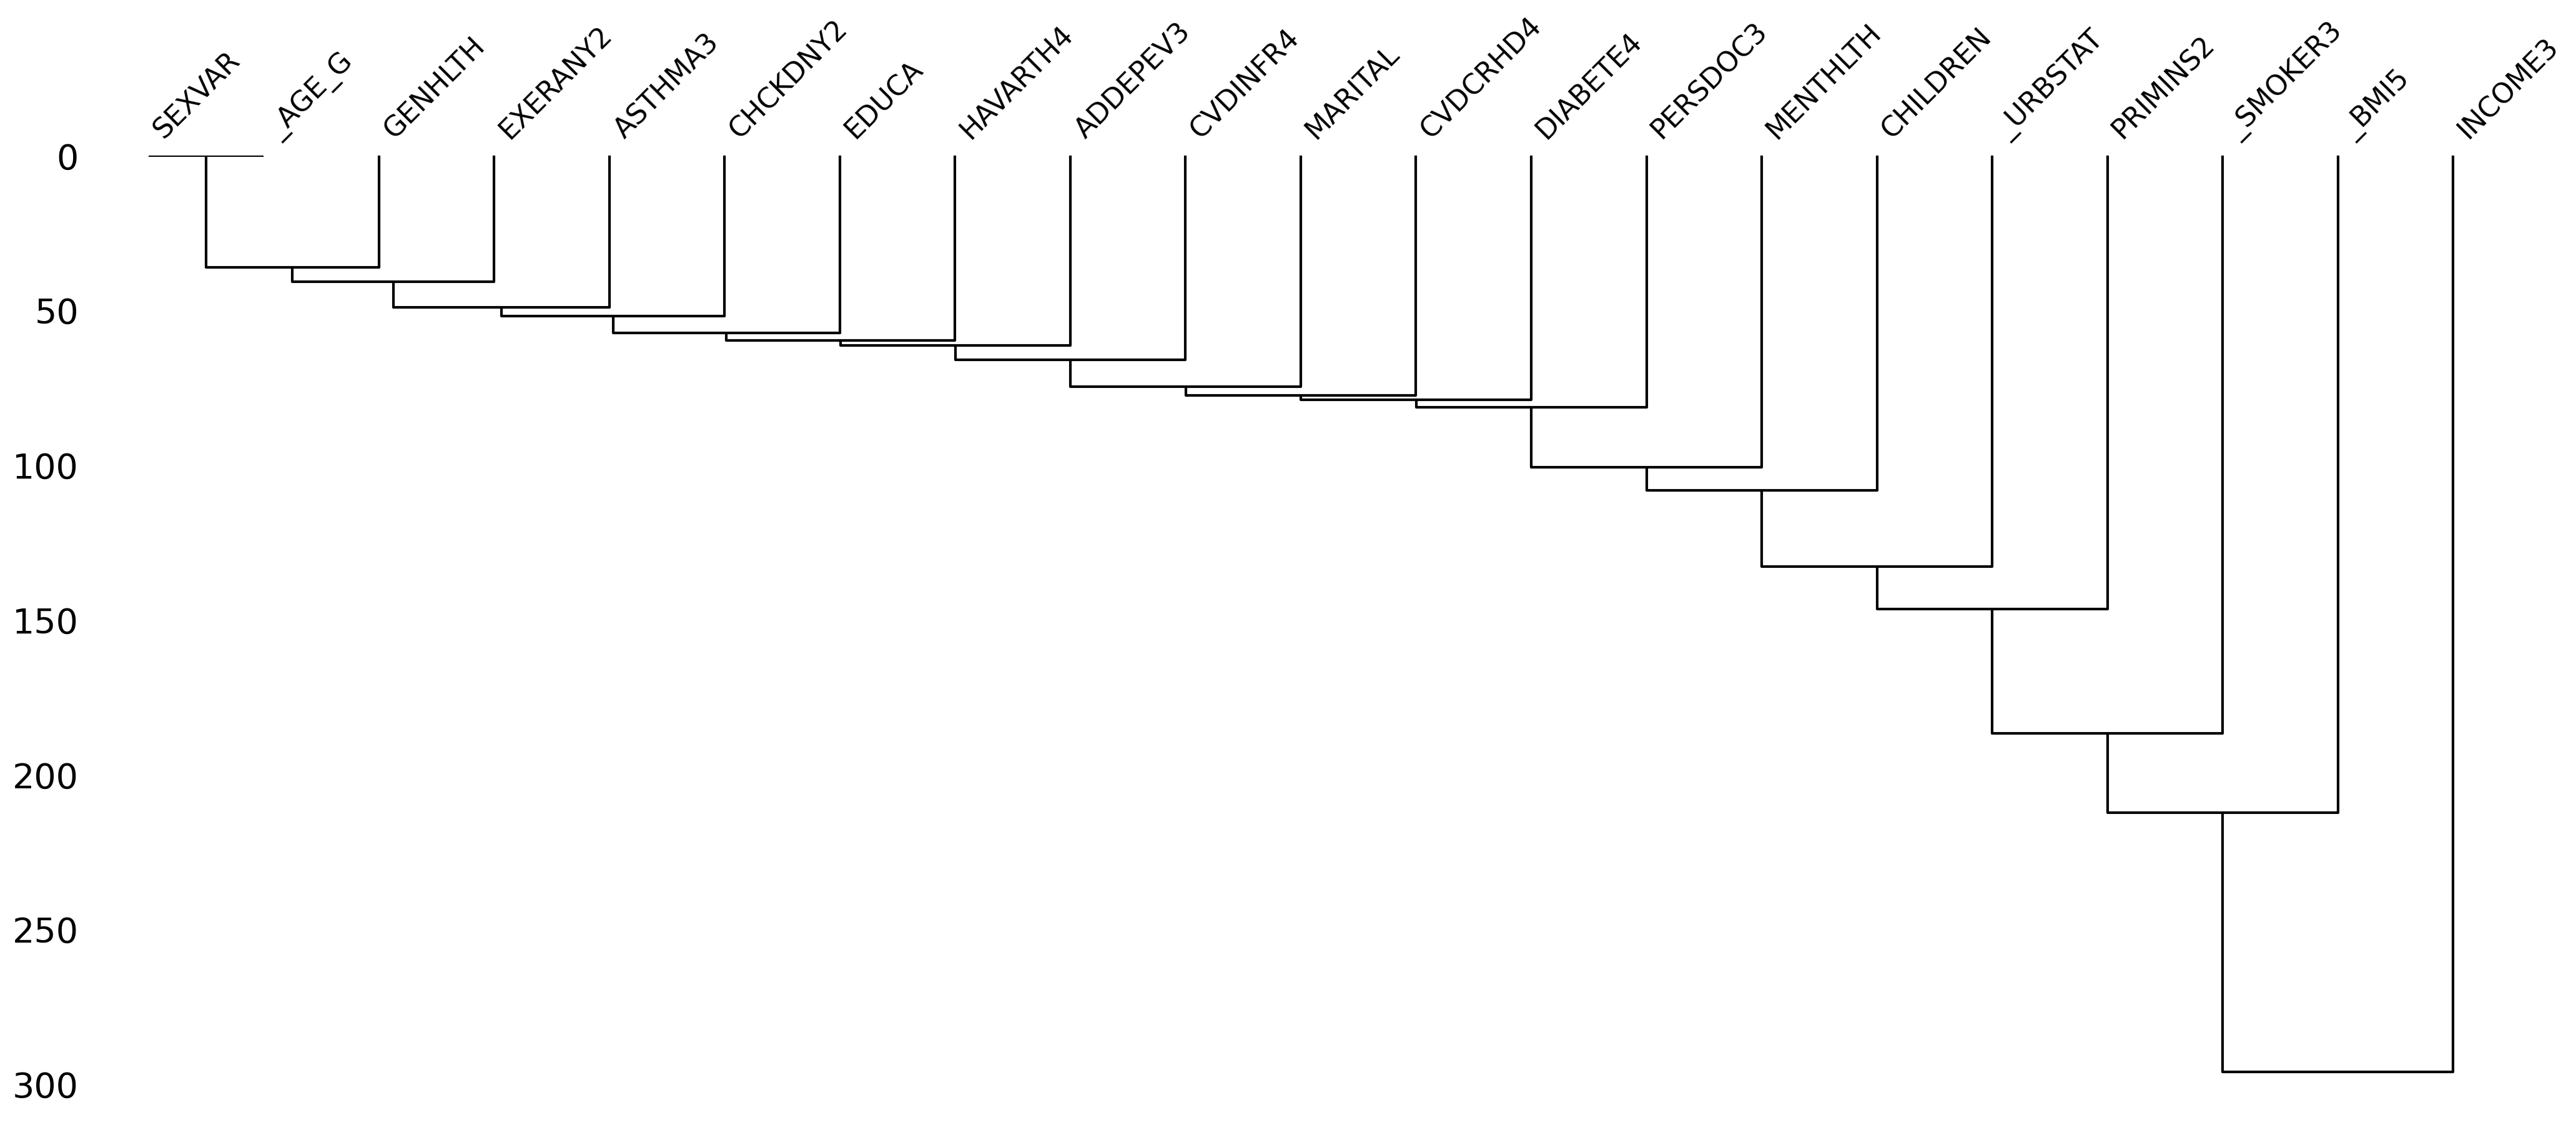

In [15]:
with plt.style.context('default'):
    msno.dendrogram(df_miss)

Okay so this confirms the sample sensitivity assumption that we had because _SMOKER3, _BMI5, and INCOME3 was merged very late and has high wand values. This means that, even though some of them might have went missing together (they have some correlation as shown at the heatmap) the reason for the misses is completely different (they are not clusterable as shown at the dendogram).

It is now concluded that this is clearly a MAR/MNAR case. Since the dendograms and the heatmap doesn't yield an immediate insight, we now need to analyze deeper some of the columns that has alarming missing values rate to see if we can impute them using other observed columns in this dataset.

Since there's a lot of columns in this dataset, and not that much time limit, We've decided that we only will be doing EDA and model-based imputaiton to only 3 of the most severe columns, which are _SMOKER3, _BMI5, INCOME3. The rest of the column will be imputed with mode, median, or mean only.   

Adapting to the time limit, I've decided that I will directly use xgboost's feature importance for the feature selection instead of manual EDA. If there's some free time left to polish this before final pitching, I will make sure to include manual EDA.

## Direct XGBoost-based feature selection

We'd need to encode the categorical first into an integer. Since XGBoost is a decision tree-based model, I think we can safely use ordinal encoder for all columns. The reason why is that even if we do one hot encoder for the nominal columns, the model will still do the same thing anyway, for example:

Let's say feature X == 'go' is important for a decision. Let's then assume this is gonna be encoded into the number '2' with ordinal encoder and encoded into a dedicated binary column 'is_X_Go' for one hot encoder.

**on ordinal-encoder**

if features X >= 1.5 and features X <= 2, then decision

**on one-hot-encoder**

if features is_X_Go == 1, then decision

XGBoost can handle both without any issues, so let's go straight into using ordinal encoder to save more time. Of course, like before, if there's extra time to experiment with this I will also try to add it.

In [16]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
income_order = ['< \$10k', '\$10k - \$15k', '\$15k - \$20k', '\$20k - \$25k', '\$25k - \$35k', 
                '\$35k - \$50k', '\$50k - \$75k', '\$75k - \$100k', '\$100k - \$150k', 
                '\$150k - \$200k', '>= \$200k']
health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
edu_order = ['Never attended/Kindergarten', 'Elementary', 'Some high school', 
             'High school graduate', 'Some college/Technical school', 'College graduate']

ordinal_cols_ordered = {
    '_AGE_G': age_order,
    'INCOME3': income_order,
    'GENHLTH': health_order,
    'EDUCA': edu_order
}


categorical_cols = [
    'DIABETE4', '_SMOKER3', 'MARITAL', 'SEXVAR', 'PERSDOC3', 
    'PRIMINS2', '_URBSTAT', 'EXERANY2', 'CVDINFR4', 'CVDCRHD4', 
    'ASTHMA3', 'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3'
]

df_encoded = df_miss.copy()

for col, order in ordinal_cols_ordered.items():
    mapping = {val: i for i, val in enumerate(order)}
    df_encoded[col] = df_encoded[col].map(mapping)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[categorical_cols] = oe.fit_transform(df_encoded[categorical_cols].astype(str))

for col in categorical_cols:
    df_encoded.loc[df_eda[col].isna(), col] = np.nan

df_encoded['MENTHLTH'] = pd.to_numeric(df_encoded['MENTHLTH'], errors='coerce')
df_encoded['CHILDREN'] = pd.to_numeric(df_encoded['CHILDREN'], errors='coerce')
df_encoded.drop(columns='DIABETE4', inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'


In [17]:
def plot_imputation_importance(importances, target_col, file_name):
    
    plt.figure(figsize=(10, 6))
    
    ax = importances.sort_values(ascending=True).plot(kind='barh', width=0.7, color="C2")
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width(), p.get_y() + p.get_height()/2),
                    ha='left', va='center', color='#FFFFFF', 
                    fontsize=10, xytext=(5, 0), textcoords='offset points')

    plt.title(f'Top Predictors for Imputing: {target_col}', 
              fontsize=14, weight='bold', color='#FFFFFF', pad=20)
    plt.xlabel('Average Gain (Importance)', fontsize=11, color='#FFFFFF')
    plt.ylabel('')
    

    plt.savefig(f'./outputs/imputations/{file_name}', transparent=True, dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

def get_imputation_features_xgb(df, target_col, file_name, is_categorical=True):
    data_complete = df.dropna(subset=[target_col])
    if len(data_complete) > 50000:
        data_complete = data_complete.sample(n=50000, random_state=42)
    
    X = data_complete.drop(columns=[target_col])
    y = data_complete[target_col]
    
    if is_categorical:
        model = XGBClassifier(
            tree_method='hist', 
            random_state=42,
            verbosity=0
        )
    else:
        model = XGBRegressor(
            tree_method='hist', 
            random_state=42,
            verbosity=0
        )
    
    model.fit(X, y)
    
    importance_scores = model.get_booster().get_score(importance_type='gain')
    importances = pd.Series(importance_scores).sort_values(ascending=False).head(10)
    
    plot_imputation_importance(importances, target_col, file_name)

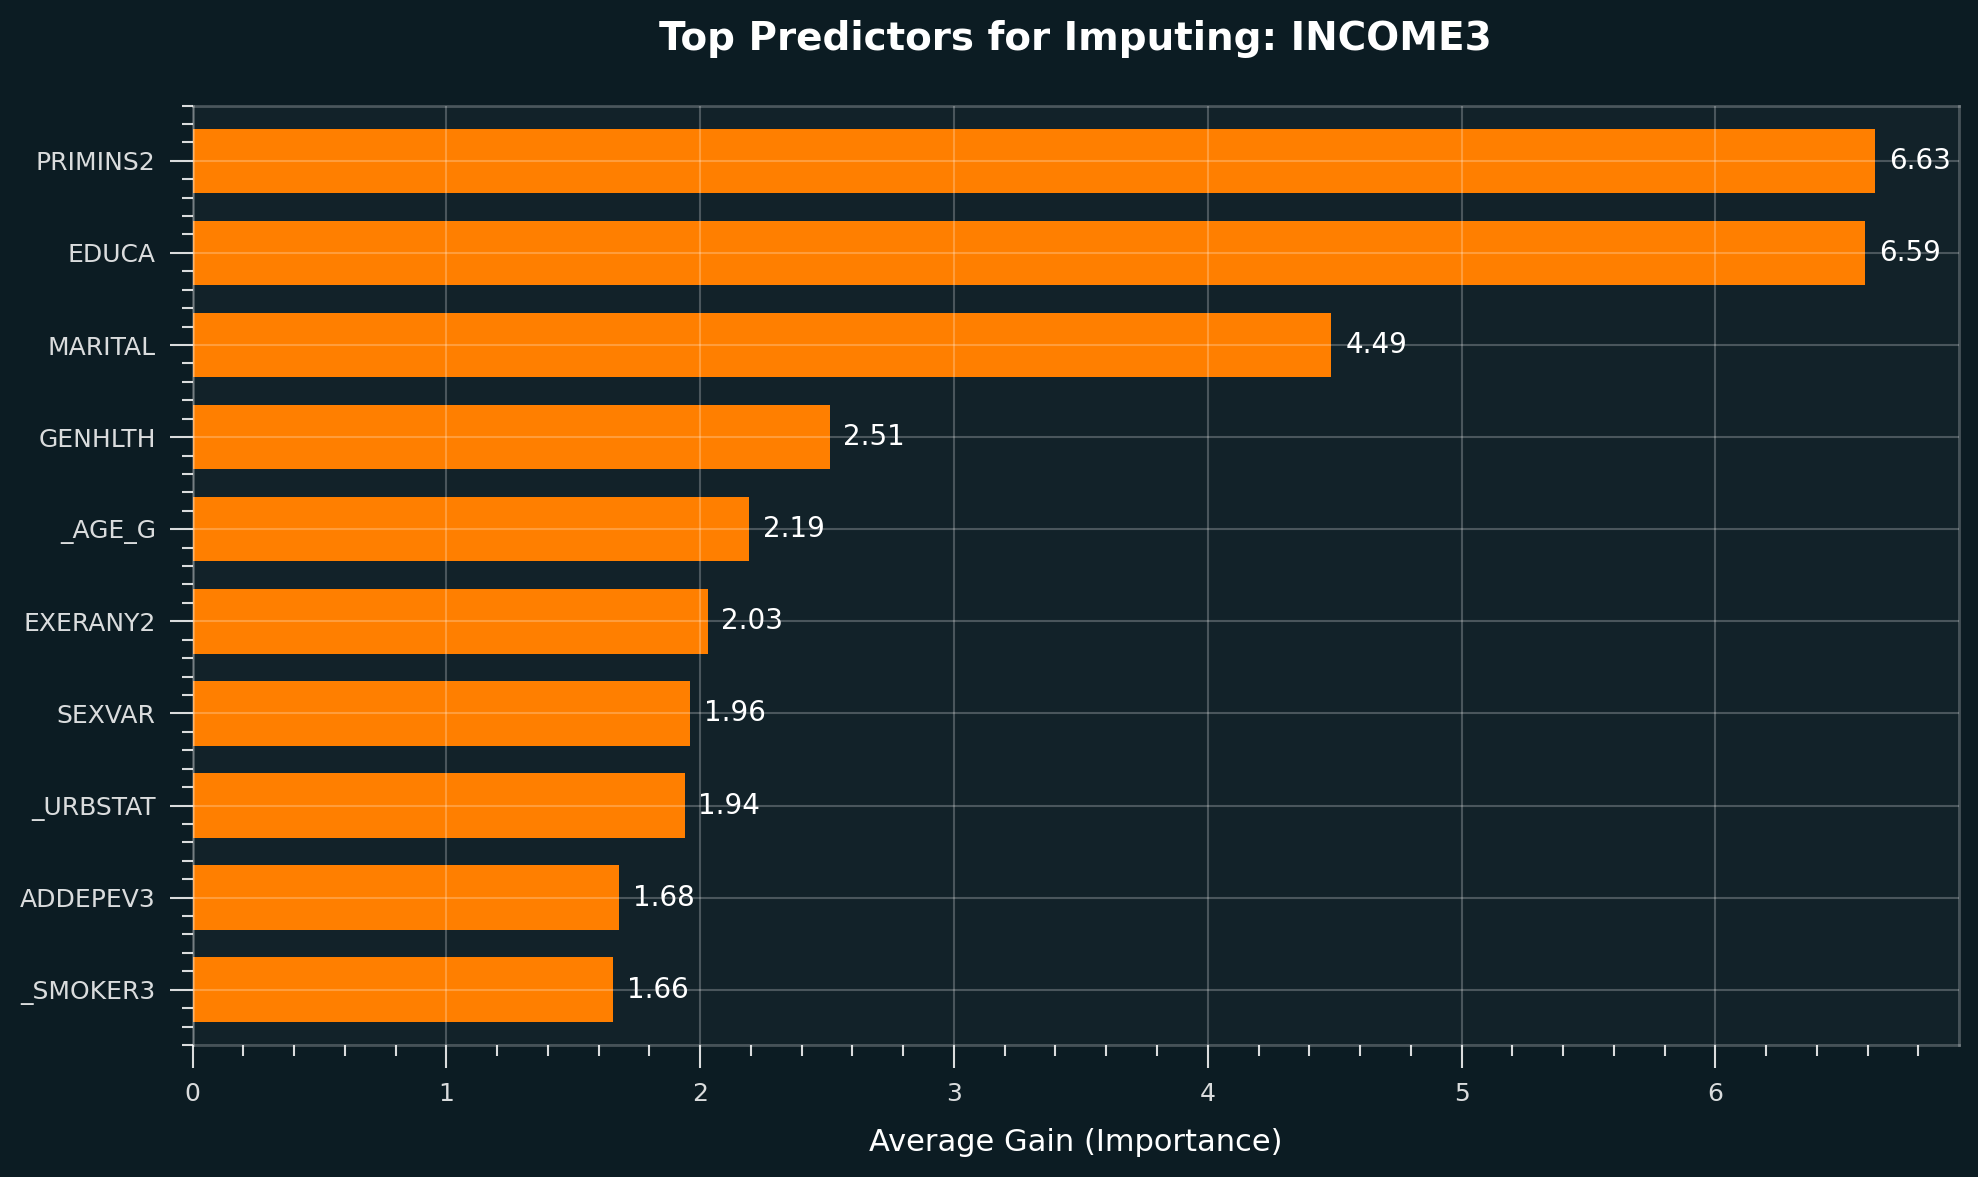

In [18]:
get_imputation_features_xgb(df_encoded, 'INCOME3', 'INCOME3_Feature_Importance', is_categorical=True)

Based on the elbow point, seems like the significant drop off happened after the _URBSTAT feautre, so for INCOME3 we will be using these features:

['PRIMINS2', 'EDUCA', 'MARITAL', 'GENHLTH', '_AGE_G', 'EXERANY2', 'SEXVAR', '_URBSTAT']

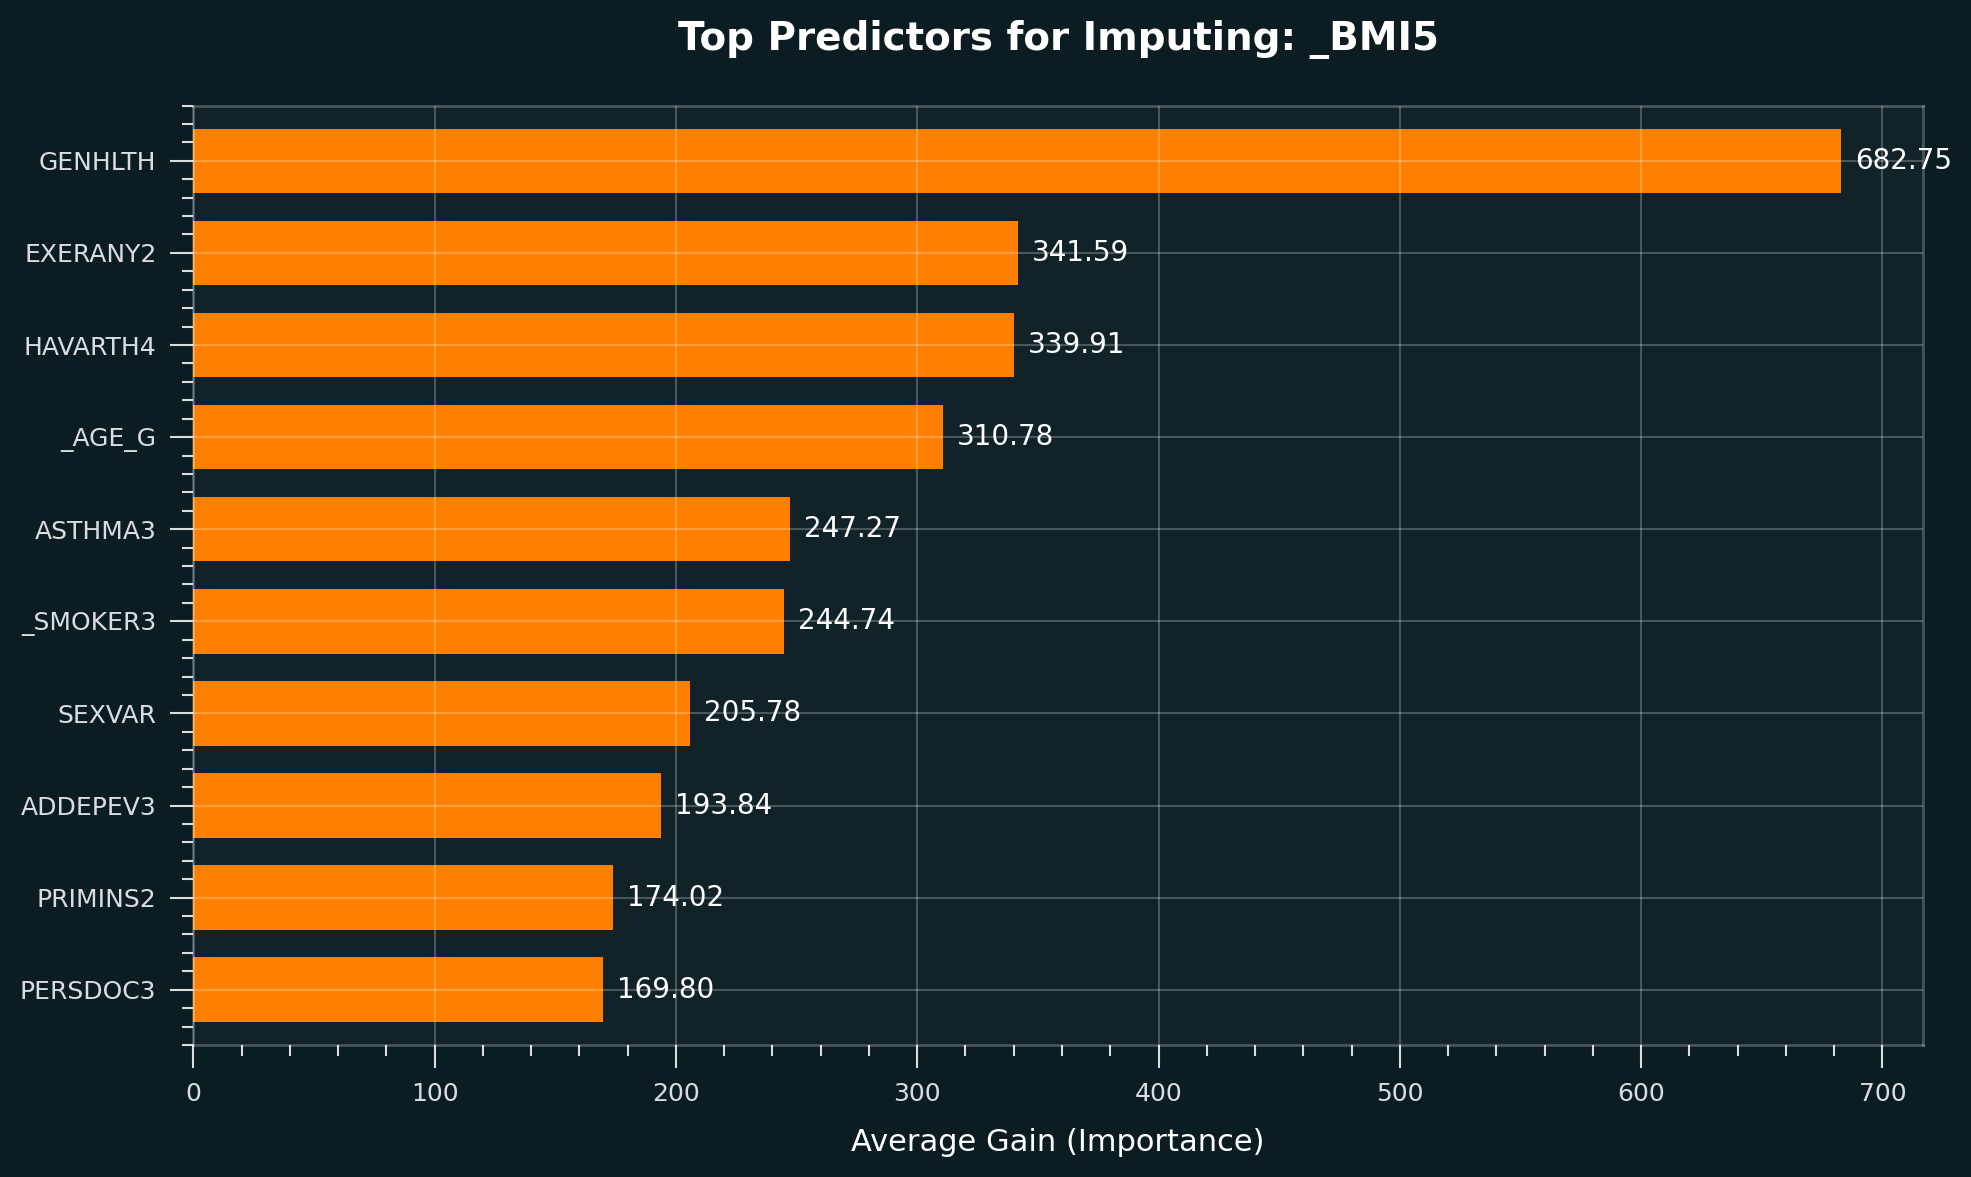

In [19]:
get_imputation_features_xgb(df_encoded, '_BMI5', 'BMI5_Feature_Importance', is_categorical=False)

Based on the elbow point, seems like the significant drop off happened after the _SMOKER3 feature, so for _BMI5 we will be using these features:

['GENHLTH', 'EXERANY2', 'HAVARTH4', '_AGE_G', 'ASTHMA3', '_SMOKER3']

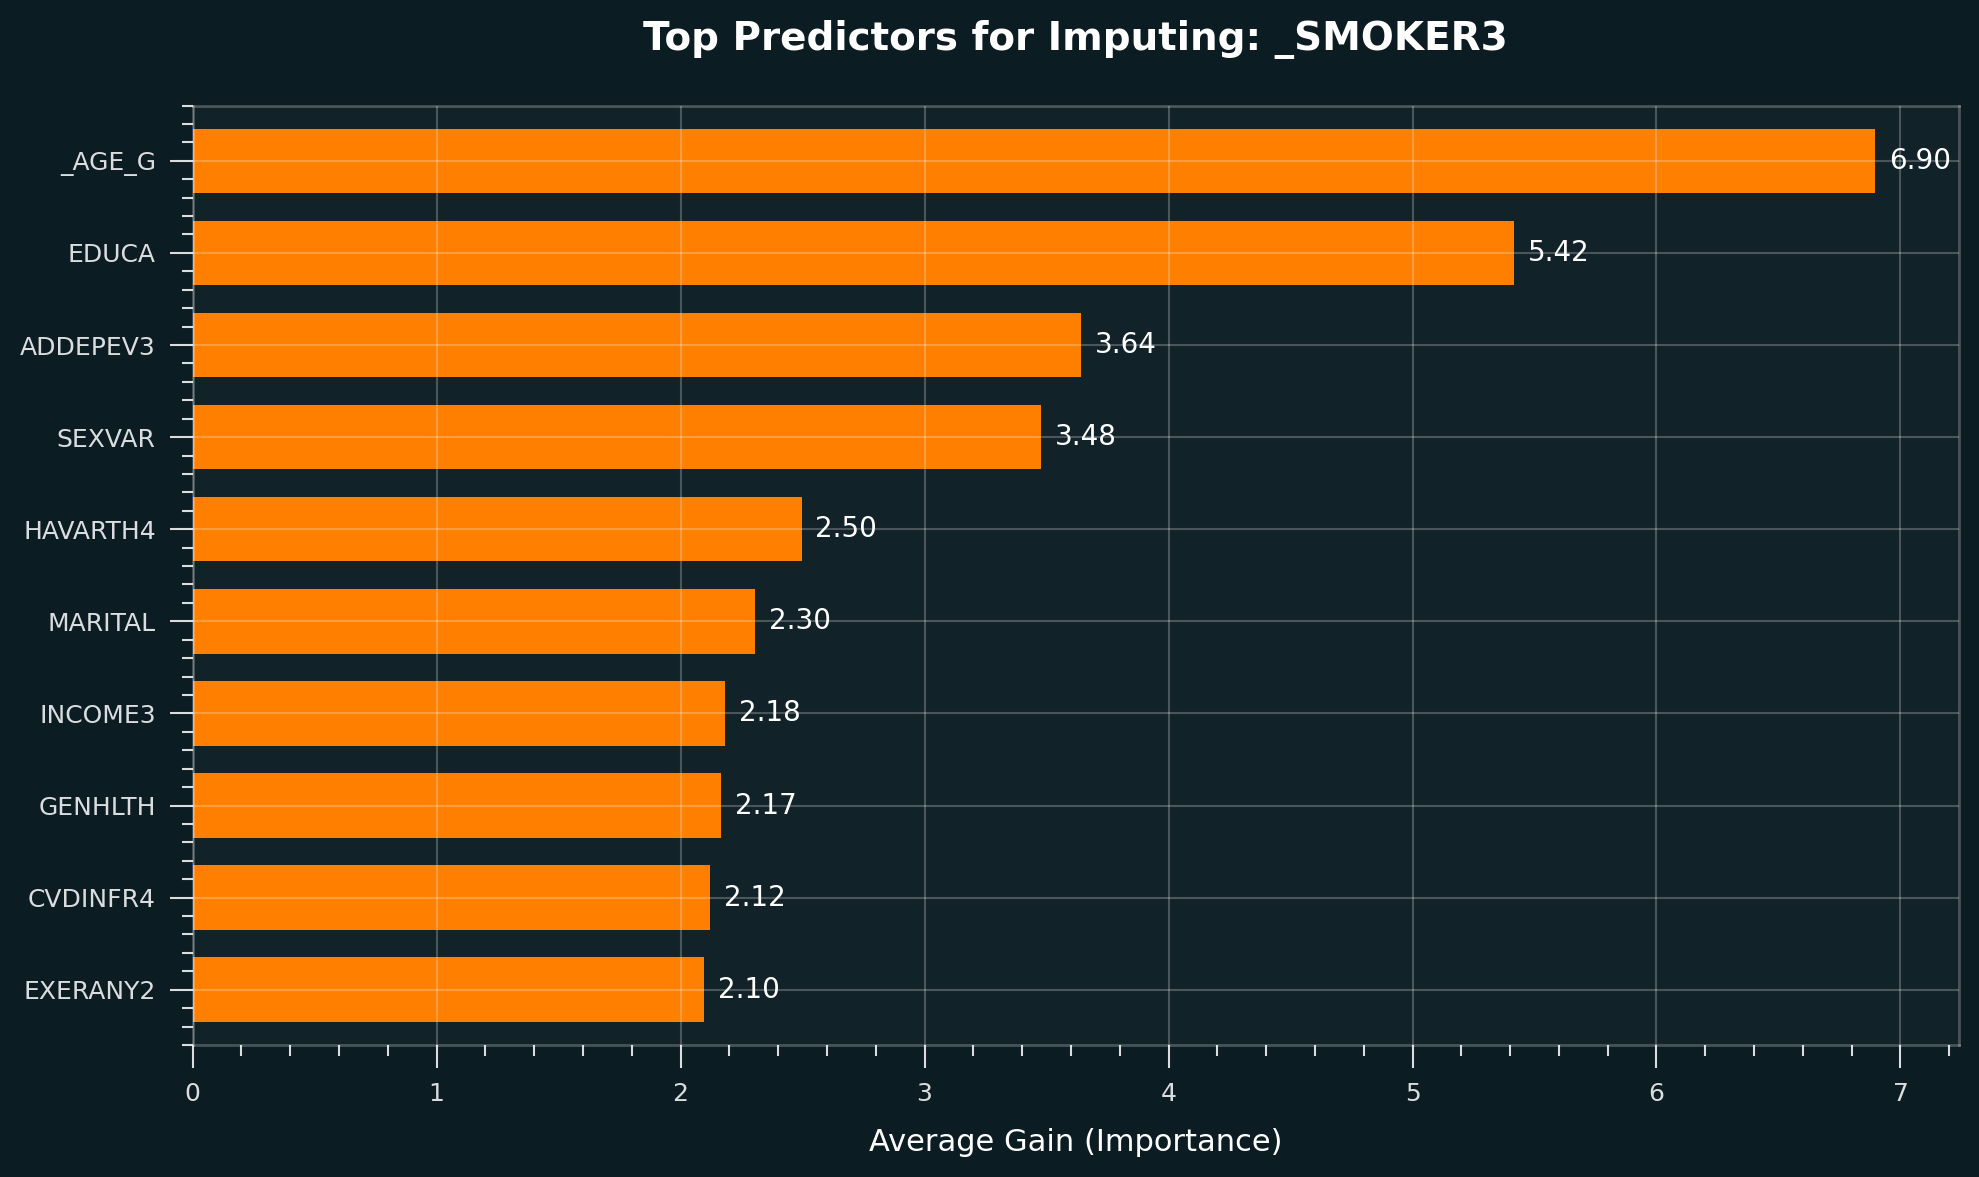

In [20]:
get_imputation_features_xgb(df_encoded, '_SMOKER3', 'SMOKER3_Feature_Importance', is_categorical=True)

Based on the elbow point, seems like the significant drop off happened after the HAVARTH4 feature, so for _SMOKER3 we will be using these features:

['_AGE_G', 'EDUCA', 'ADDEPEV3', 'SEXVAR', 'HAVARTH4']

## Conclusion

After doing missing feature analysis, we have decided to experiment with keeping unknown labels and imputation because its clearly not a MCAR case. For the imputation, based on the feature importance analysis and judging by the elbow points, we have decided to use these set of features for each alarming columns.

**INCOME3**

['PRIMINS2', 'EDUCA', 'MARITAL', 'GENHLTH', '_AGE_G', 'EXERANY2', 'SEXVAR', '_URBSTAT']

**_BMI5**

['GENHLTH', 'EXERANY2', 'HAVARTH4', '_AGE_G', 'ASTHMA3', '_SMOKER3']

**_SMOKER3**

['_AGE_G', 'EDUCA', 'ADDEPEV3', 'SEXVAR', 'HAVARTH4']

# Outlier Analysis

Let's first do an outlier analysis on the numerical columns, which are _BMI5, CHILDREN, and MENTHLTH. I'd assume that all of them is going to be right skewed. My another assumption is that _BMI5 and MENTHLTH column will be having a lot of natural outliers while CHILDREN column is to just be super weird since the dictionary states that the maximum value is somehow 83??. Let's see the boxplots of each columns and proceed from there.

/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


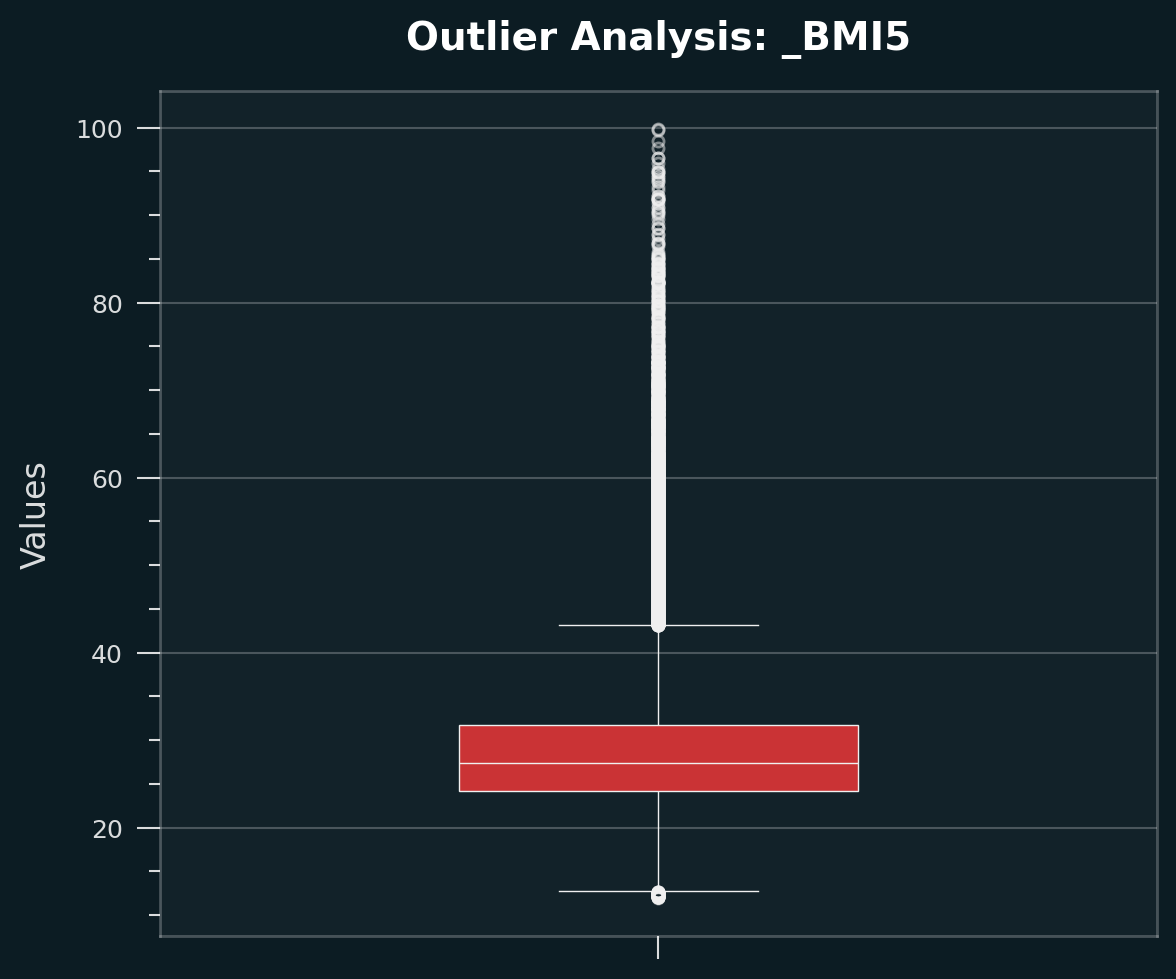

/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


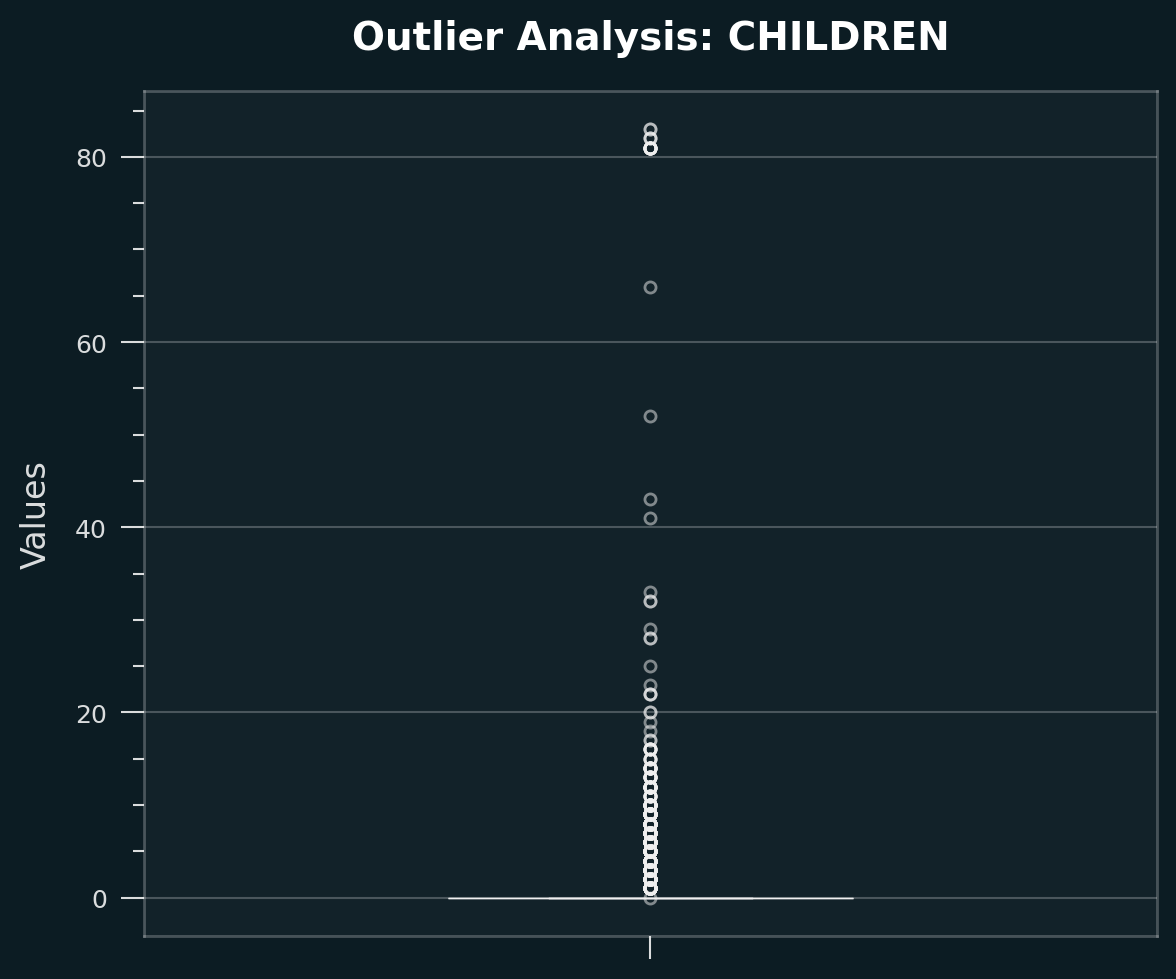

/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


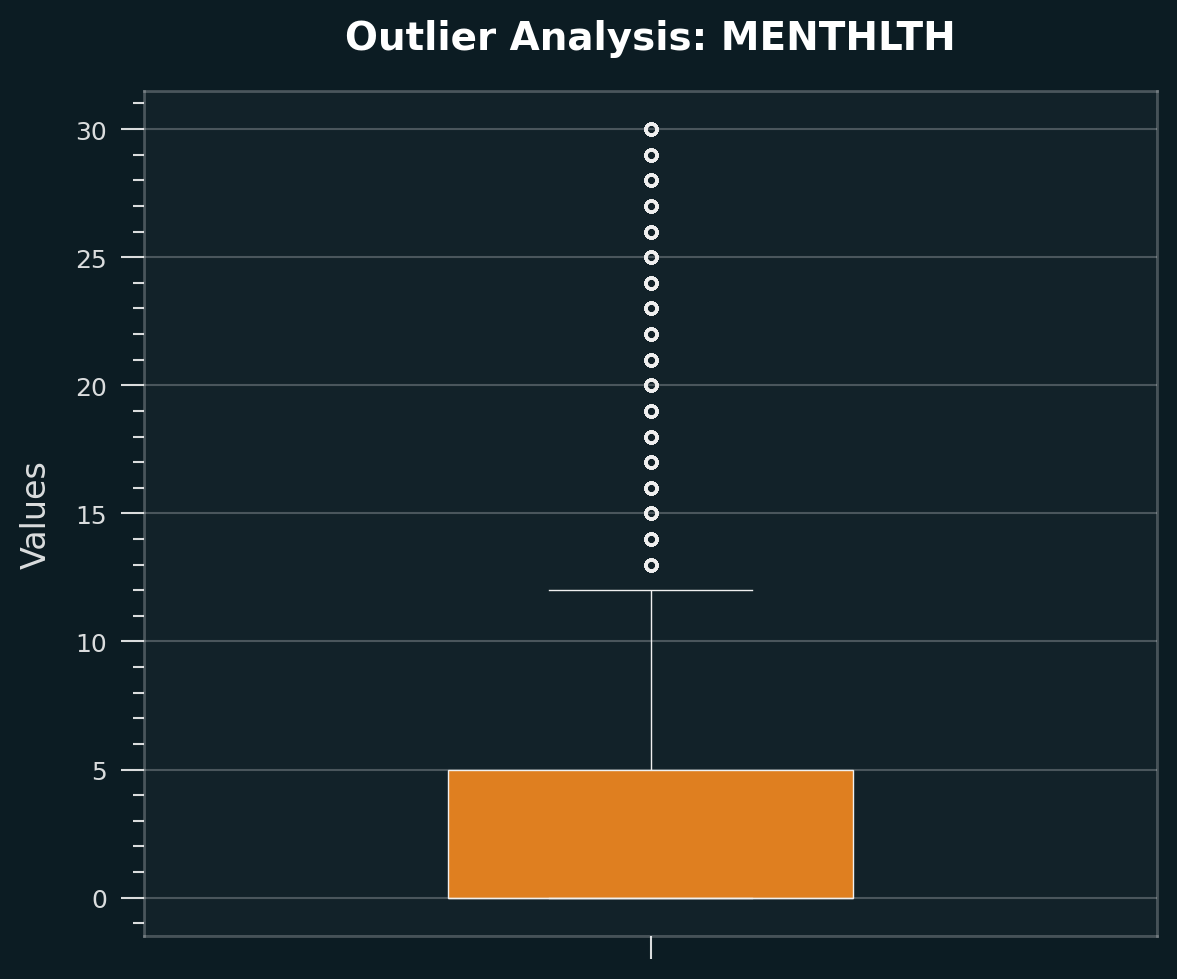

In [21]:
numerical_cols = ['_BMI5', 'CHILDREN', 'MENTHLTH']

colors = ['C0', 'C1', 'C2']
edge_color = '#f0f0f0'

for col, color in zip(numerical_cols, colors):
    plt.figure(figsize=(6, 5))
    
    clean_data = pd.to_numeric(df_eda[col], errors='coerce').dropna()
    
    sns.boxplot(
        y=clean_data, 
        color=color, 
        width=0.4,
        boxprops=dict(edgecolor=edge_color, linewidth=0.5),
        medianprops=dict(color=edge_color, linewidth=0.5),
        whiskerprops=dict(color=edge_color, linewidth=0.5),
        capprops=dict(color=edge_color, linewidth=0.5),
        flierprops=dict(markeredgecolor=edge_color, markerfacecolor='none', alpha=0.5)
    )
    
    plt.title(f'Outlier Analysis: {col}', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Values', fontsize=12)

    plt.savefig(f"./outputs/modelling/{col}_boxplot.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
    plt.tight_layout()
    plt.show()
    plt.close()

Seems like _BMI5 is the only one that was successfully plotted here with my initial assumption on it having natural outliers being absolutely spot on. CHILDREN column will definitely need a unique way to plot it, I'm planning to maybe find out how many are having 5+ childrens to decide whether I should just merge them into one later. MENTHLTH column is super interesting because I CANNOT see the median. I'm assuming the median is probably at the bottom IQR since it is the most common value according to the data dictionary.

Let's first address the CHILDREN column by finding out the outliers percentage. I'll try to find an elbow point to create a new (x+) category.

In [22]:
children_clean = pd.to_numeric(df_eda['CHILDREN'], errors='coerce').dropna()

for i in range (0, 20):
    total_entries = len(children_clean)
    count_plus = len(children_clean[children_clean >= i])
    percentage_plus = (count_plus / total_entries) * 100
    print(f"Percentage of families with {i}+ children: {percentage_plus:.2f}%")

Percentage of families with 0+ children: 100.00%
Percentage of families with 1+ children: 24.98%
Percentage of families with 2+ children: 14.23%
Percentage of families with 3+ children: 5.56%
Percentage of families with 4+ children: 1.97%
Percentage of families with 5+ children: 0.70%
Percentage of families with 6+ children: 0.29%
Percentage of families with 7+ children: 0.14%
Percentage of families with 8+ children: 0.07%
Percentage of families with 9+ children: 0.04%
Percentage of families with 10+ children: 0.03%
Percentage of families with 11+ children: 0.02%
Percentage of families with 12+ children: 0.02%
Percentage of families with 13+ children: 0.02%
Percentage of families with 14+ children: 0.01%
Percentage of families with 15+ children: 0.01%
Percentage of families with 16+ children: 0.01%
Percentage of families with 17+ children: 0.01%
Percentage of families with 18+ children: 0.01%
Percentage of families with 19+ children: 0.01%


Okay there is an interesting drop at 4+ and 5+ childrens, let's visualize this and clip it to 6+ to try understand the percentages better.

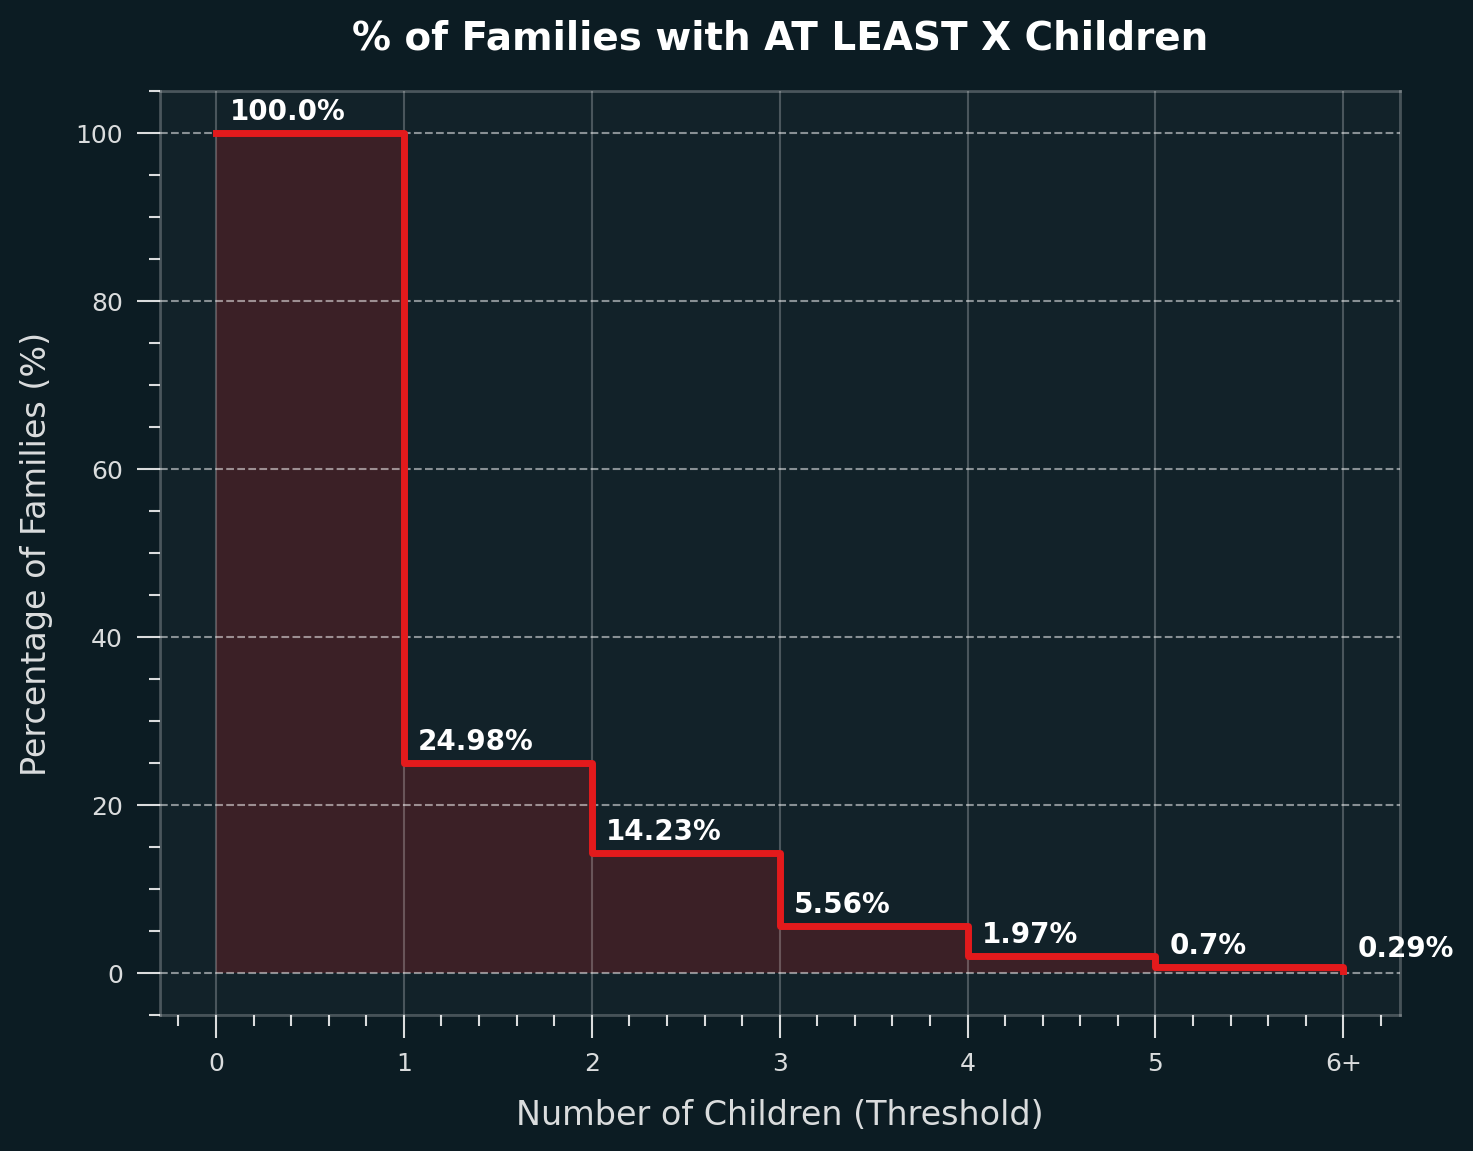

In [23]:
plt.figure(figsize=(8, 6))

thresholds = list(range(0, 7))
percentages = [100.0, 24.98, 14.23, 5.56, 1.97, 0.70, 0.29]

plt.step(thresholds, percentages, where='post', linewidth=2.5)
plt.fill_between(thresholds, percentages, step="post", alpha=0.2)

plt.title('% of Families with AT LEAST X Children', fontsize=14, fontweight='bold')
plt.xlabel('Number of Children (Threshold)', fontsize=12)
plt.ylabel('Percentage of Families (%)', fontsize=12)
plt.xticks(thresholds, ['0', '1', '2', '3', '4', '5', '6+'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

for x, y in zip(thresholds, percentages):
    plt.annotate(f'{y}%', (x, y), textcoords="offset points", xytext=(5,5), ha='left', fontweight='bold', fontsize=10)
    
plt.savefig(f"./outputs/modelling/family_children_elbow.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()


Seems like merging it into a 4+ category is a safe bet. Even though we could push it to 5+, once we hit that 4-child threshold, we’re already looking at just 1.97% of the entire population.

By grouping them here, we’re capturing the 'Large Family' demographic without letting the extreme, single digit outliers. Those 10 or 20+ counts could distort our general distribution as shown in the boxplot previously. It also simplifies the model's job: instead of trying to find a linear relationship between '15 children' and 'BMI,' it can focus on the much more meaningful jump from having 0 kids to having a full house.

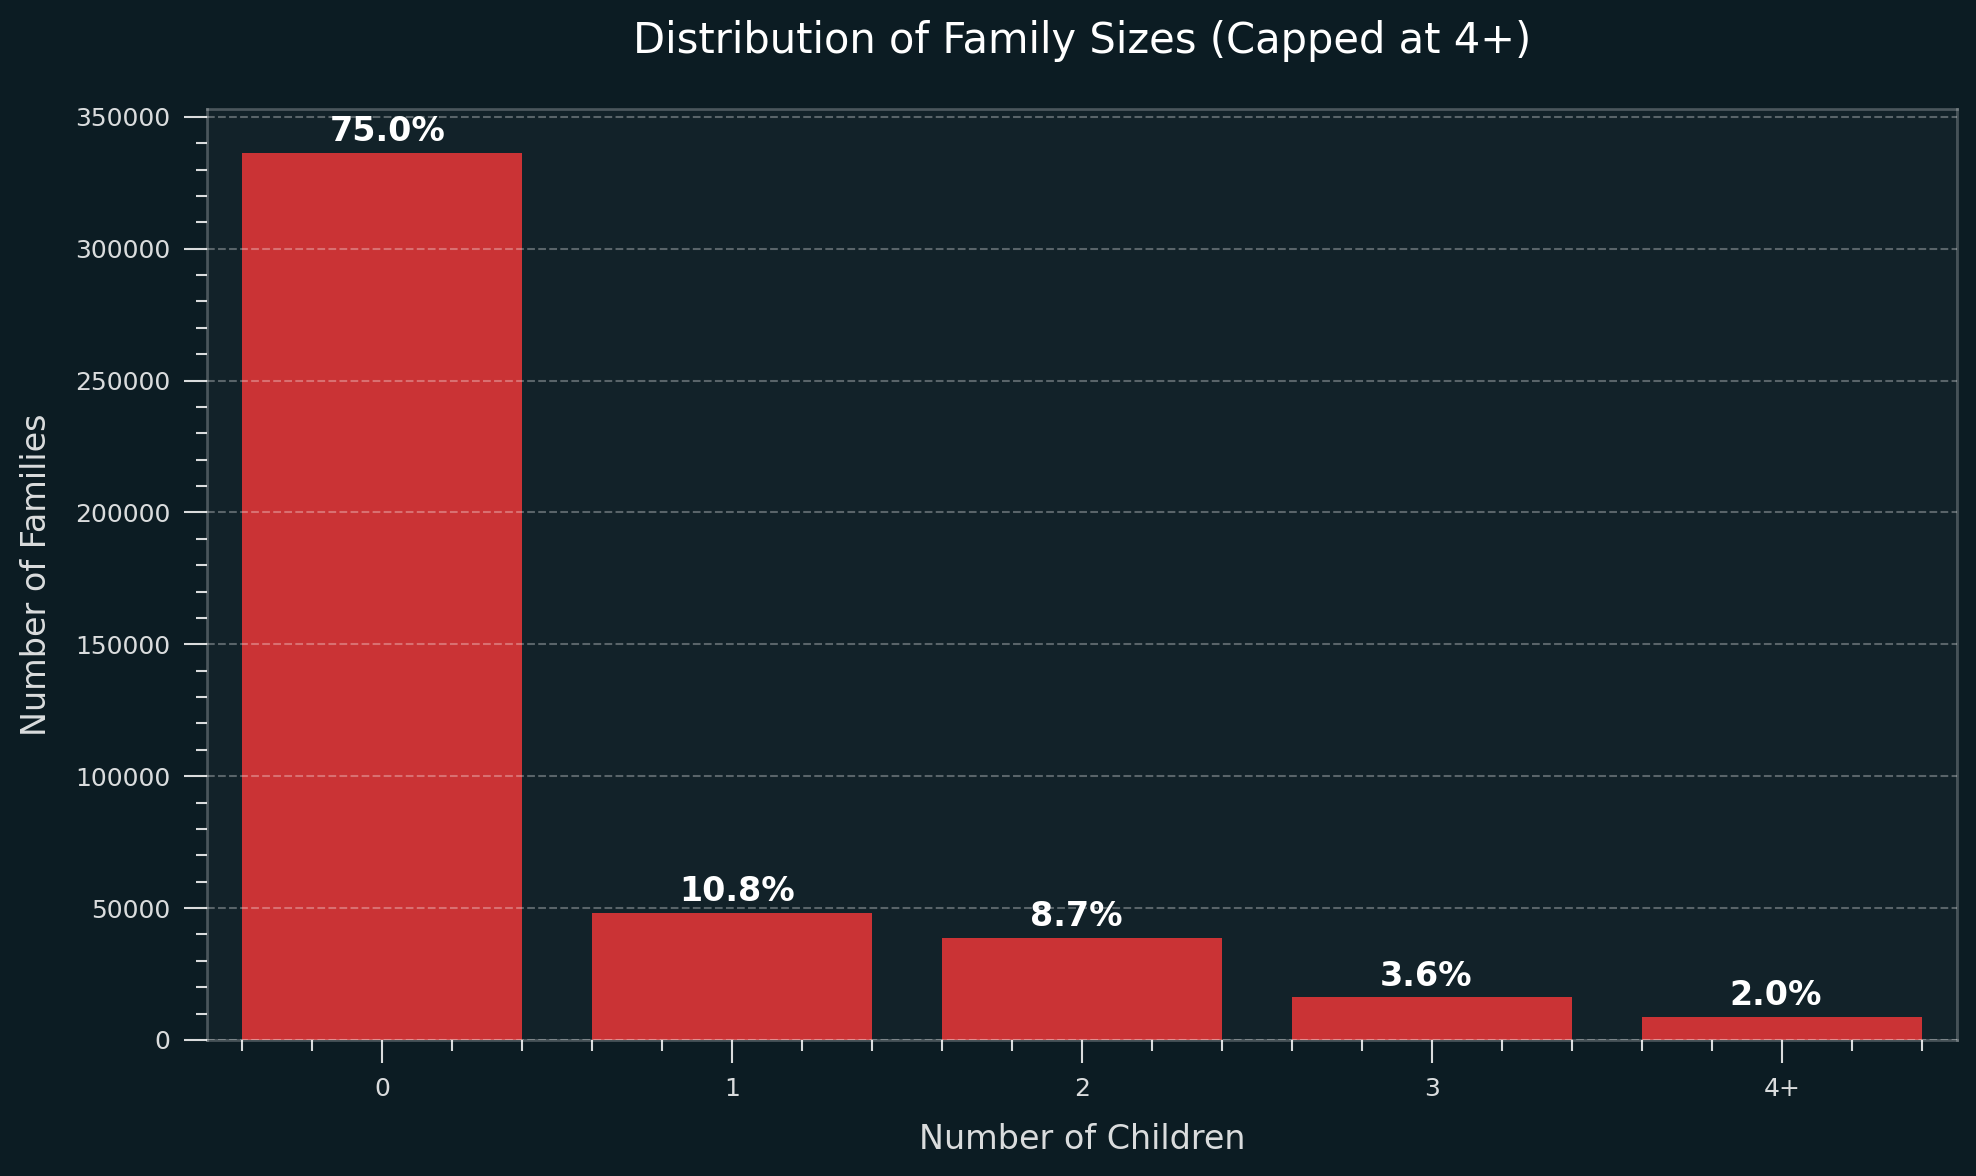

In [24]:
df_eda['CHILDREN_CLEANED'] = pd.to_numeric(df_eda['CHILDREN'], errors='coerce')
df_eda['CHILDREN_CAPPED'] = df_eda['CHILDREN_CLEANED'].clip(upper=4)
df_eda['CHILDREN_CAPPED'] = df_eda['CHILDREN_CAPPED'].round(0).astype('Int64')

plt.figure(figsize=(10, 6))

ax = sns.countplot(x='CHILDREN_CAPPED', data=df_eda, color='C0')

total = len(df_eda['CHILDREN_CAPPED'].dropna())
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Distribution of Family Sizes (Capped at 4+)', fontsize=15, pad=20)
plt.xlabel('Number of Children', fontsize=12)
plt.ylabel('Number of Families', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['0', '1', '2', '3', '4+'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.savefig(f"./outputs/modelling/family_children_count.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.tight_layout()
plt.show()

Nice, now the distribution looks more realistic. Keeping them as 4+ instead of dropping them should be okay as we are just treating them as natural outliers. Let's now move on to checking the non-existent median value of the MENTHLTH column. I'm assuming the median might have merged with the bottom IQR since probably not that much people that feel like they have days where their mental health feels problematic. Let's numerically just check it

In [33]:
menthlth_data = pd.to_numeric(df_eda['MENTHLTH'], errors='coerce').dropna()

menthlth_stats = menthlth_data.describe(percentiles=[.25, .5, .75])

print("--- Mental Health Statistics ---")
print(f"25th Percentile (Q1): {menthlth_stats['25%']}")
print(f"50th Percentile (Median): {menthlth_stats ['50%']}")
print(f"75th Percentile (Q3): {menthlth_stats ['75%']}")

--- Mental Health Statistics ---
25th Percentile (Q1): 0.0
50th Percentile (Median): 0.0
75th Percentile (Q3): 5.0


Yep, it is now confirmed that the reason it was gone was because it merged with the bottom IQR due to the most common values actually being the same as the lower IQR values. This just means that there's more people who feel like they have 0 days of bad mental health days (meaning, they don't feel like their mental health is bad at all in the past month), which is pretty expected since mental health issue is not that common yet. Let's now move on to distribution analysis

# Distribution Analysis 

Okay, let's now move on to check each continous column's distribution to see whether there is a skewed column or not. I will also immediately experiment here regarding which transformation to use that actually fix the skewness of the data.

Let's start with BMI column

/tmp/ipykernel_25794/1843814045.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


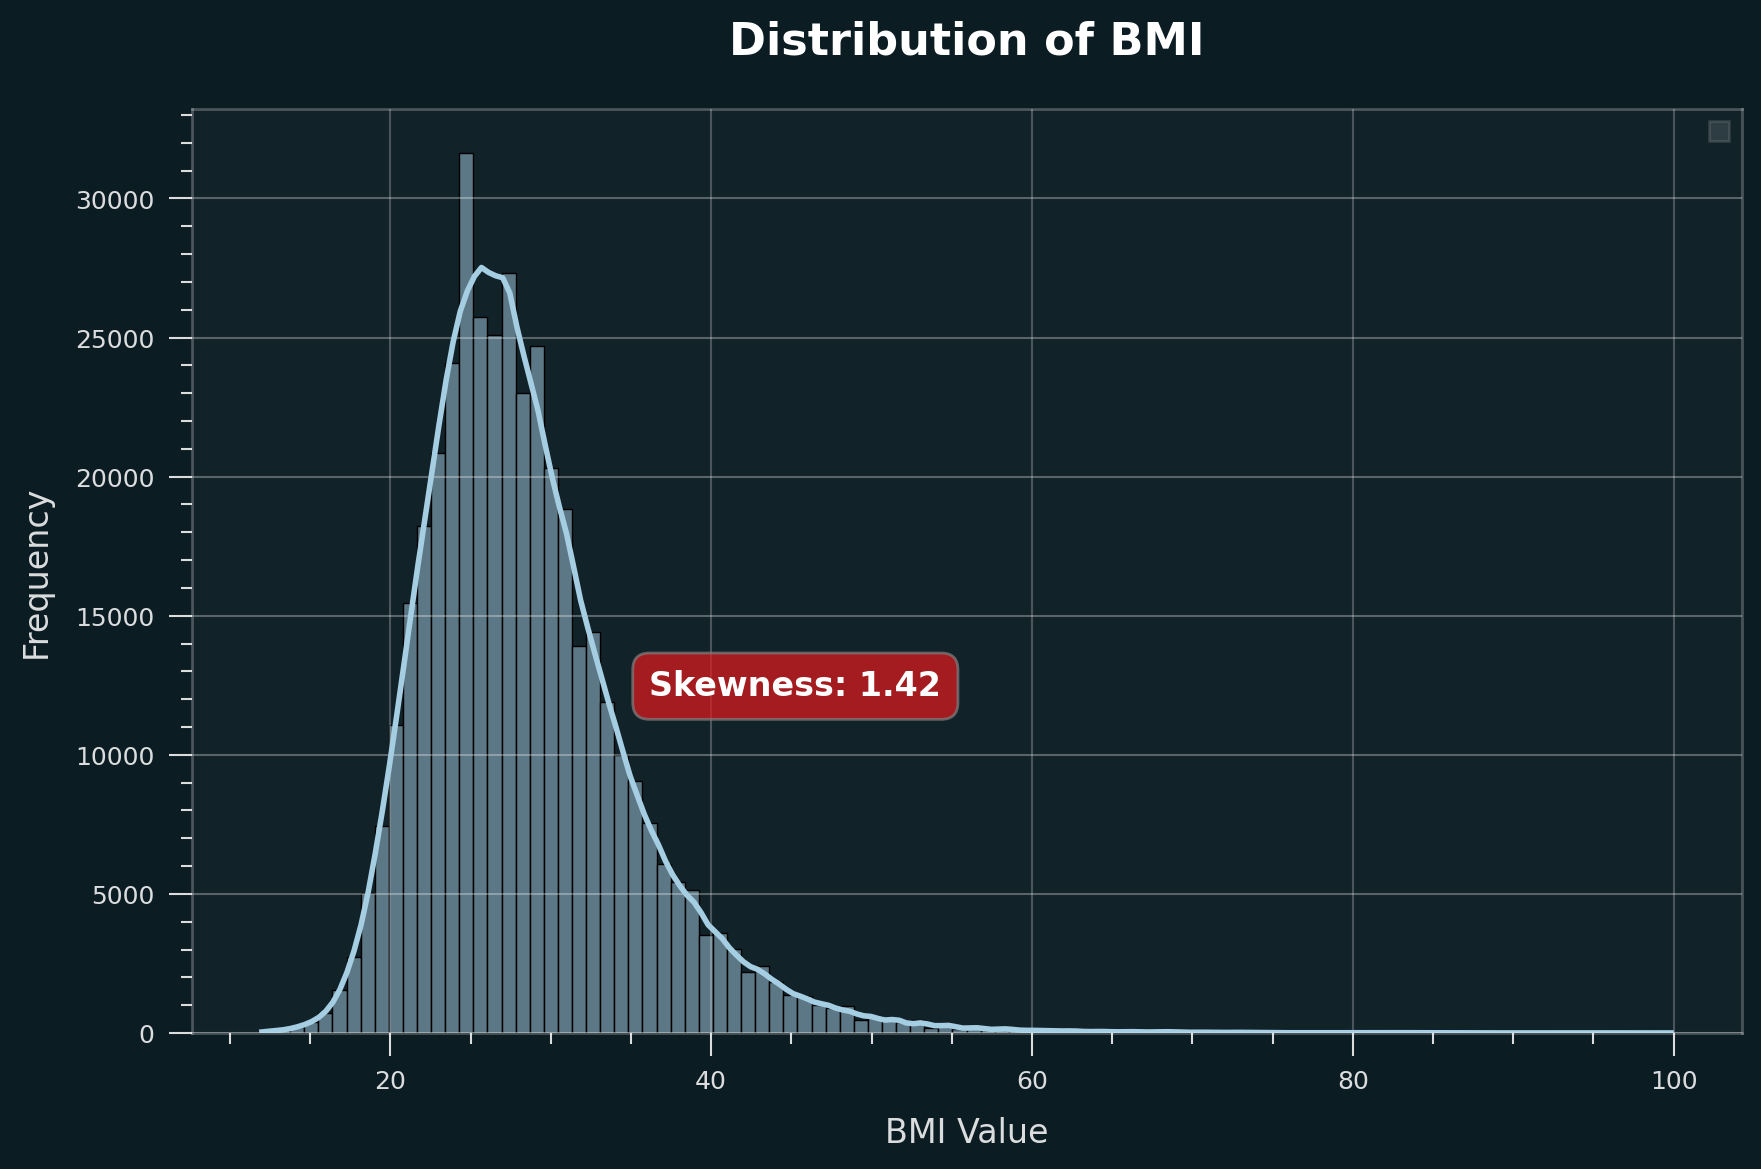

In [26]:
bmi_data = pd.to_numeric(df_eda['_BMI5'], errors='coerce').dropna()

plt.figure(figsize=(10, 6))

sns.histplot(bmi_data, 
             kde=True, 
             color='C8', 
             line_kws={'color': 'lightred', 'lw': 2},
             bins=100)

plt.text(0.95, 0.91, f'Skewness: {bmi_data.skew():.2f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='C0', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Distribution of BMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('BMI Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.savefig(f"./outputs/modelling/BMI_Distribution.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

Okay, the BMI column is clearly right-skewed, with it can be classified as highly skewed because the skewness is > 1. We will be trying some transformation methods later to try fix this skewness. Now, since we already handled the CHILDREN columns by merging the outliers into a single category, let's jump straight into analyzing MENTHLTH column. This column is an interesting one since it is technically a discrete data (we can't really count 2.5 days, that would be weird?), but I feel like it can still be treated as a continuous variable due to the amount of discrete point that it have. Let's do exactly that and plot them with histogram + kde.

/tmp/ipykernel_25794/2926678501.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


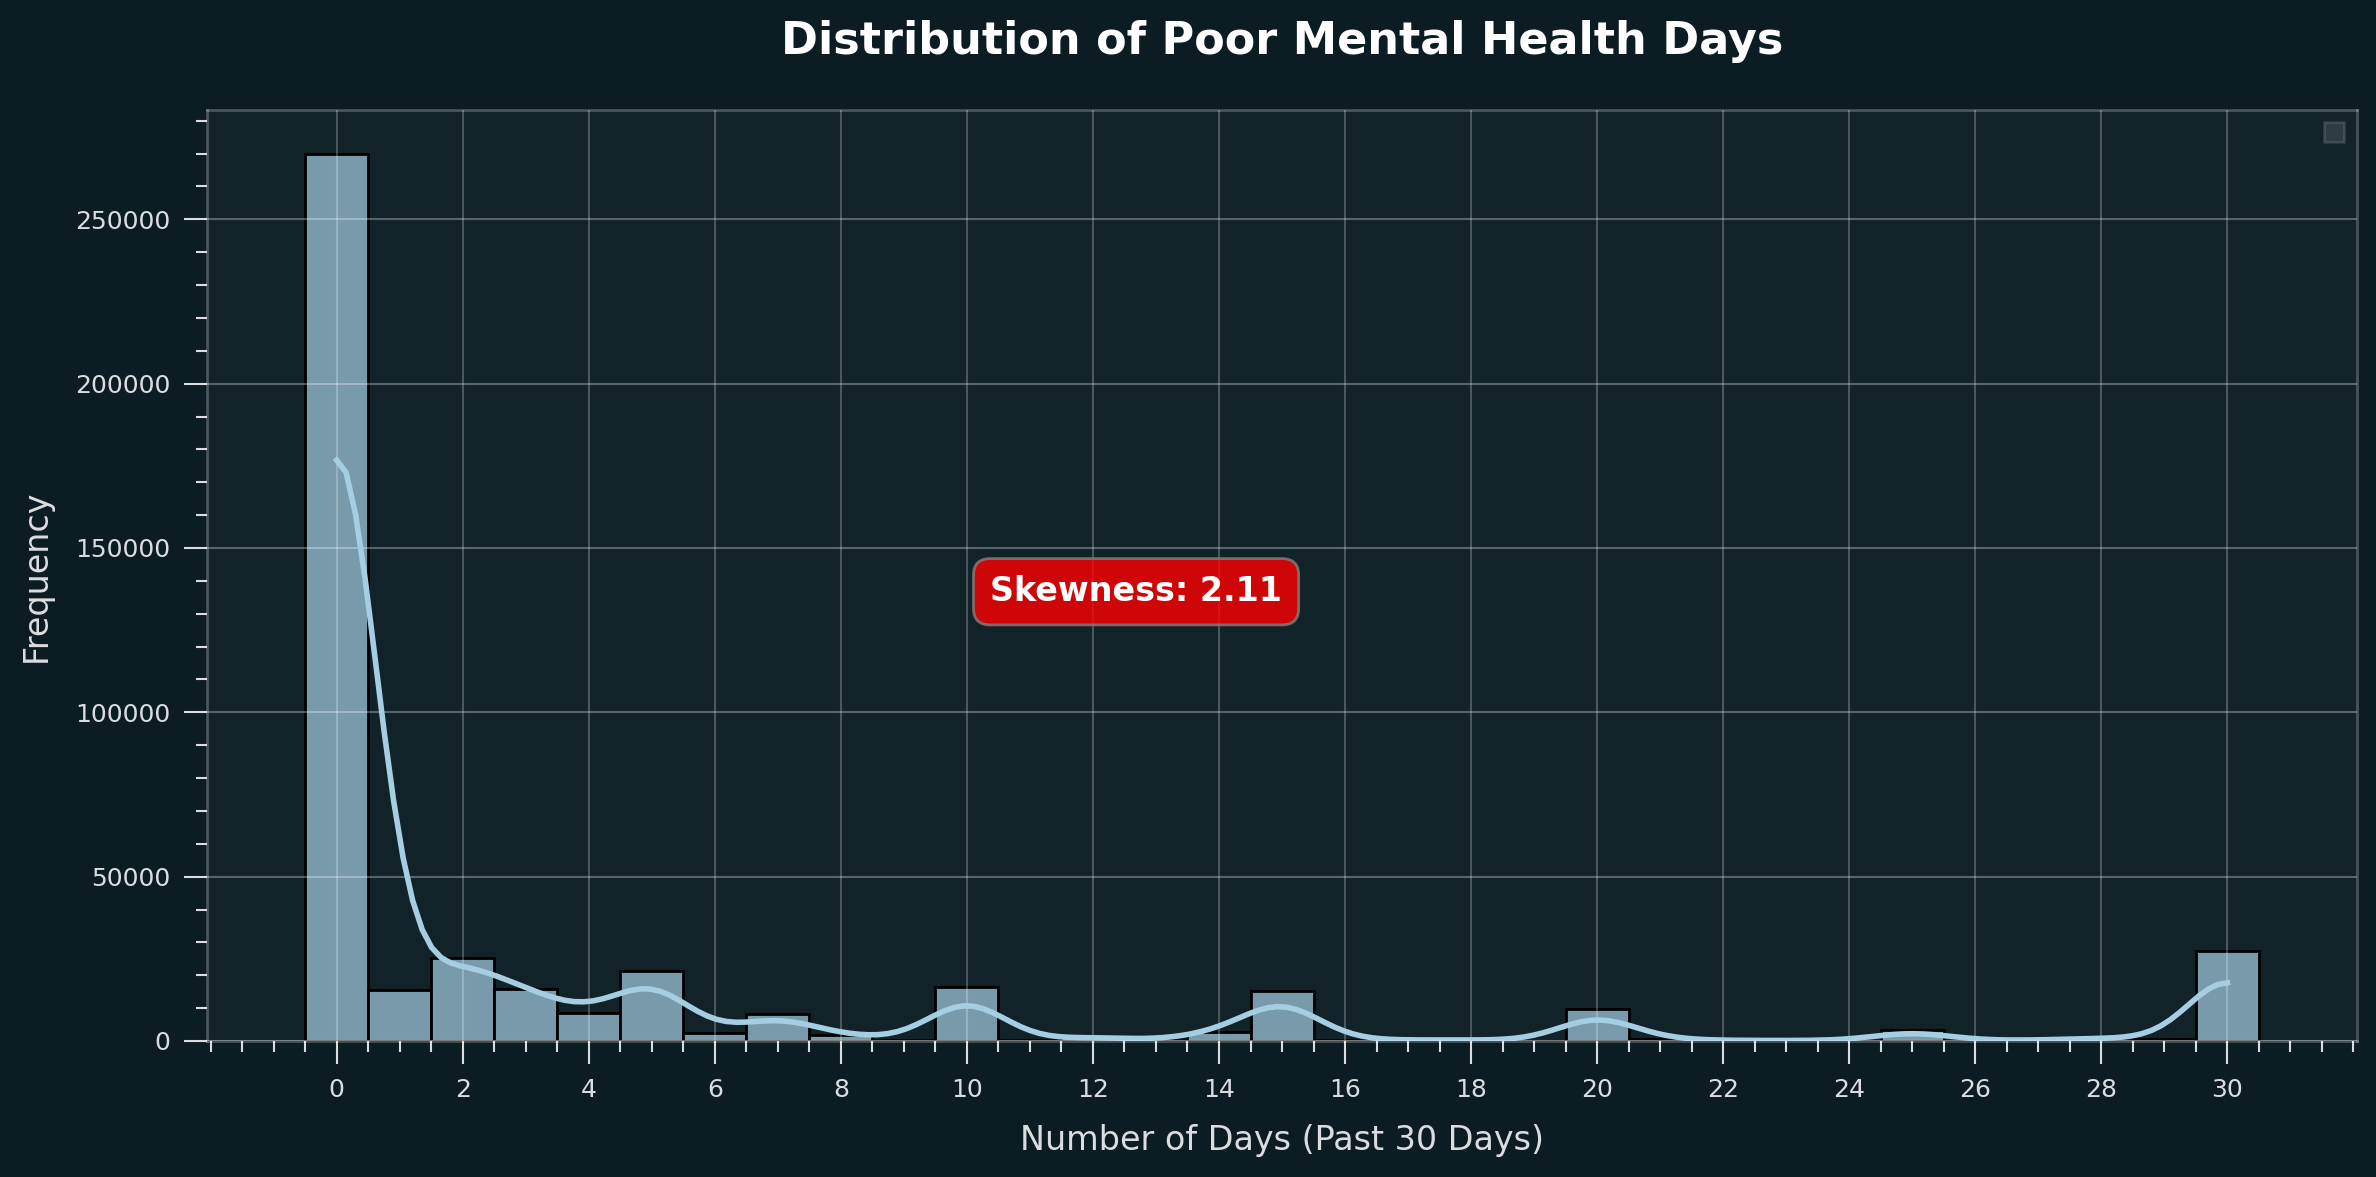

In [27]:
mental_data = pd.to_numeric(df_eda['MENTHLTH'], errors='coerce').dropna()

mh_skew = mental_data.skew()

plt.figure(figsize=(12, 6))

ax = sns.histplot(mental_data, 
                 kde=True, 
                 discrete=True, 
                 color='C8', 
                 line_kws={'color': 'red', 'lw': 2},
                 edgecolor='black',
                 alpha=0.7)

plt.text(0.5, 0.5, f'Skewness: {mh_skew:.2f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='red', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))


plt.title('Distribution of Poor Mental Health Days', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Days (Past 30 Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(0, 31, 2)) # Show every 2nd day for clarity
plt.legend()

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"./outputs/modelling/MENTHLTH_Distribution.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

Damn, looking at the plot above, we have a massive zero-inflation situation. A massive chunk of the population reports 0 days of poor mental health, which creates that massive spike at the beginning of our histogram and a massive skewness of 2.11. In a distribution like this, the mean value is pretty much lying to us. If we just throw this raw column into a model, that giant zero-bar is going to drown out the actual signal from the people who are struggling. I'm thinking we should do try the Hurdle Model approach here. Since the data is split between "I'm doing fine" and "I'm struggling (1-30 days)," let's treat them that way. I'm thinking of a two-step Feature Engineering (FE) strategy:

1. The "Hurdle" (Binary Flag): Create a simple 1 or 0 feature. Did they report any bad days? This captures the fundamental "Healthy vs. At-Risk" state.
2. The "Intensity" (Continuous Feature): For the people who cleared that hurdle (reported 1+ days), how many days was it?

Let's check the distribution of that 1–30 subset first to check for skewness.

/tmp/ipykernel_25794/3958282205.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


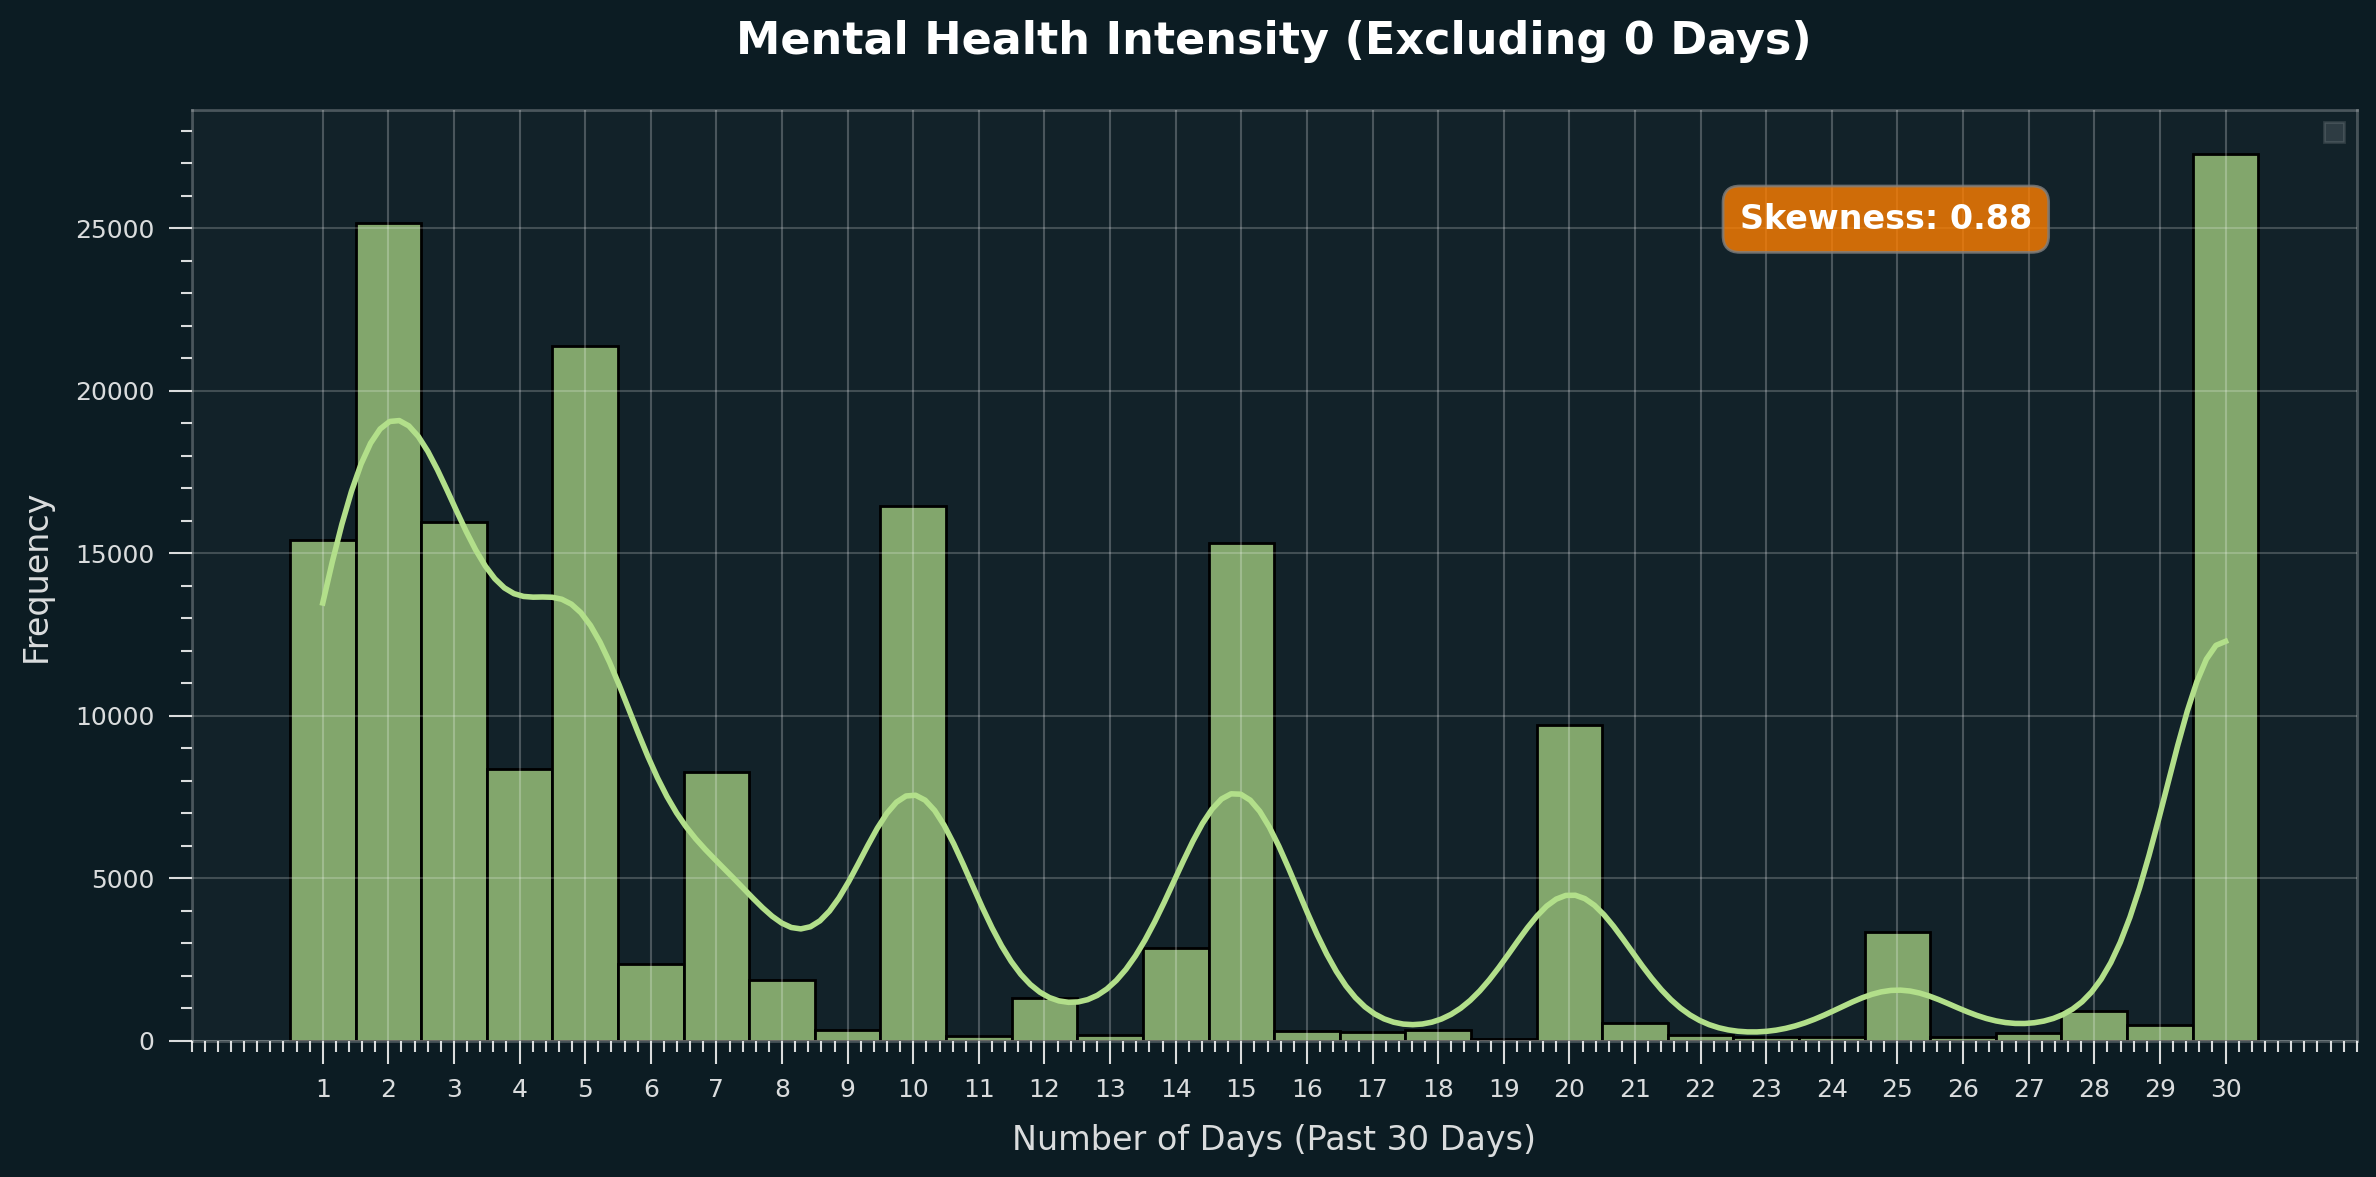

In [28]:
distressed_only = pd.to_numeric(df_eda['MENTHLTH'], errors='coerce').dropna()
distressed_only = distressed_only[distressed_only > 0]

intensity_skew = distressed_only.skew()

plt.figure(figsize=(12, 6))

ax = sns.histplot(distressed_only, 
                 kde=True, 
                 discrete=True, 
                 color='C6',
                 line_kws={'color': 'red', 'lw': 2},
                 edgecolor='black',
                 alpha=0.7)

plt.text(0.85, 0.90, f'Skewness: {intensity_skew:.2f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='C2', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))


plt.title('Mental Health Intensity (Excluding 0 Days)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Days (Past 30 Days)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(1, 31, 1))
plt.legend()

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(f"./outputs/modelling/MENTHLTH_Distribution_hurdle.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

Wow, okay, that's interesting, By taking away the zeros, the skewness lowered from a scary 2.11 to a much more reasonable 0.88. Looking at the new plot, we can clearly see the 'Human Factor' where people love rounding their bad days to multiples of 5 (5, 10, 15...). We even have a significant 'Chronic' group sitting right at the 30-day mark.

Since 0.88 is within the moderately-skewed range, I'm not going to do any transformation for this column since it's a weirdly distributed data that already has a solid reasoning behind it. We've successfully isolated the 'If' (the binary flag) from the 'How Much' (this intensity column). This Hurdle approach gives us a much cleaner signal for the model to work with.

## BMI Transformation Experiment

Now that we're done with all the numerical column, let's move on to BMI transformation experiment. The 1.42 right-skewness is a bit of a problem. It’s got a long, heavy tail stretching out toward 100, which can really mess with the sanity of linear models. If we leave it as is, the model might get obsessed with those extreme outliers and lose track of the typical person.

We’re going to go for a head-to-head comparison of three classic transformation techniques to see which one handles the skewness best:

##### 1. Log Transformation:

The classic. It’s great at shrinking large values more than small ones.
$$ f(x)=ln(x) $$
Its basically transforming like this: "The difference between a BMI of 20 and 25 is way more important than the difference between 70 and 75.". Some log transformation uses ln(x+1) to handle ln(0), but since our BMI column does not have 0, we can just safely ignore it.

##### 2. Square Root Transformation:

A middle-ground approach. It’s less aggressive than the Log but still helps pull in that right-side tail.
$$ f(x)=\sqrt{x} $$

##### 3. Box-cox Transformation:

The "smart" option. This is a power transformation that actually searches for the mathematically optimal lambda (λ) to make the data as normal as possible. It’s like letting the data choose its own best shape.
$$f(x; \lambda) = 
\begin{cases} 
\frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ 
\ln(x) & \text{if } \lambda = 0 
\end{cases}$$

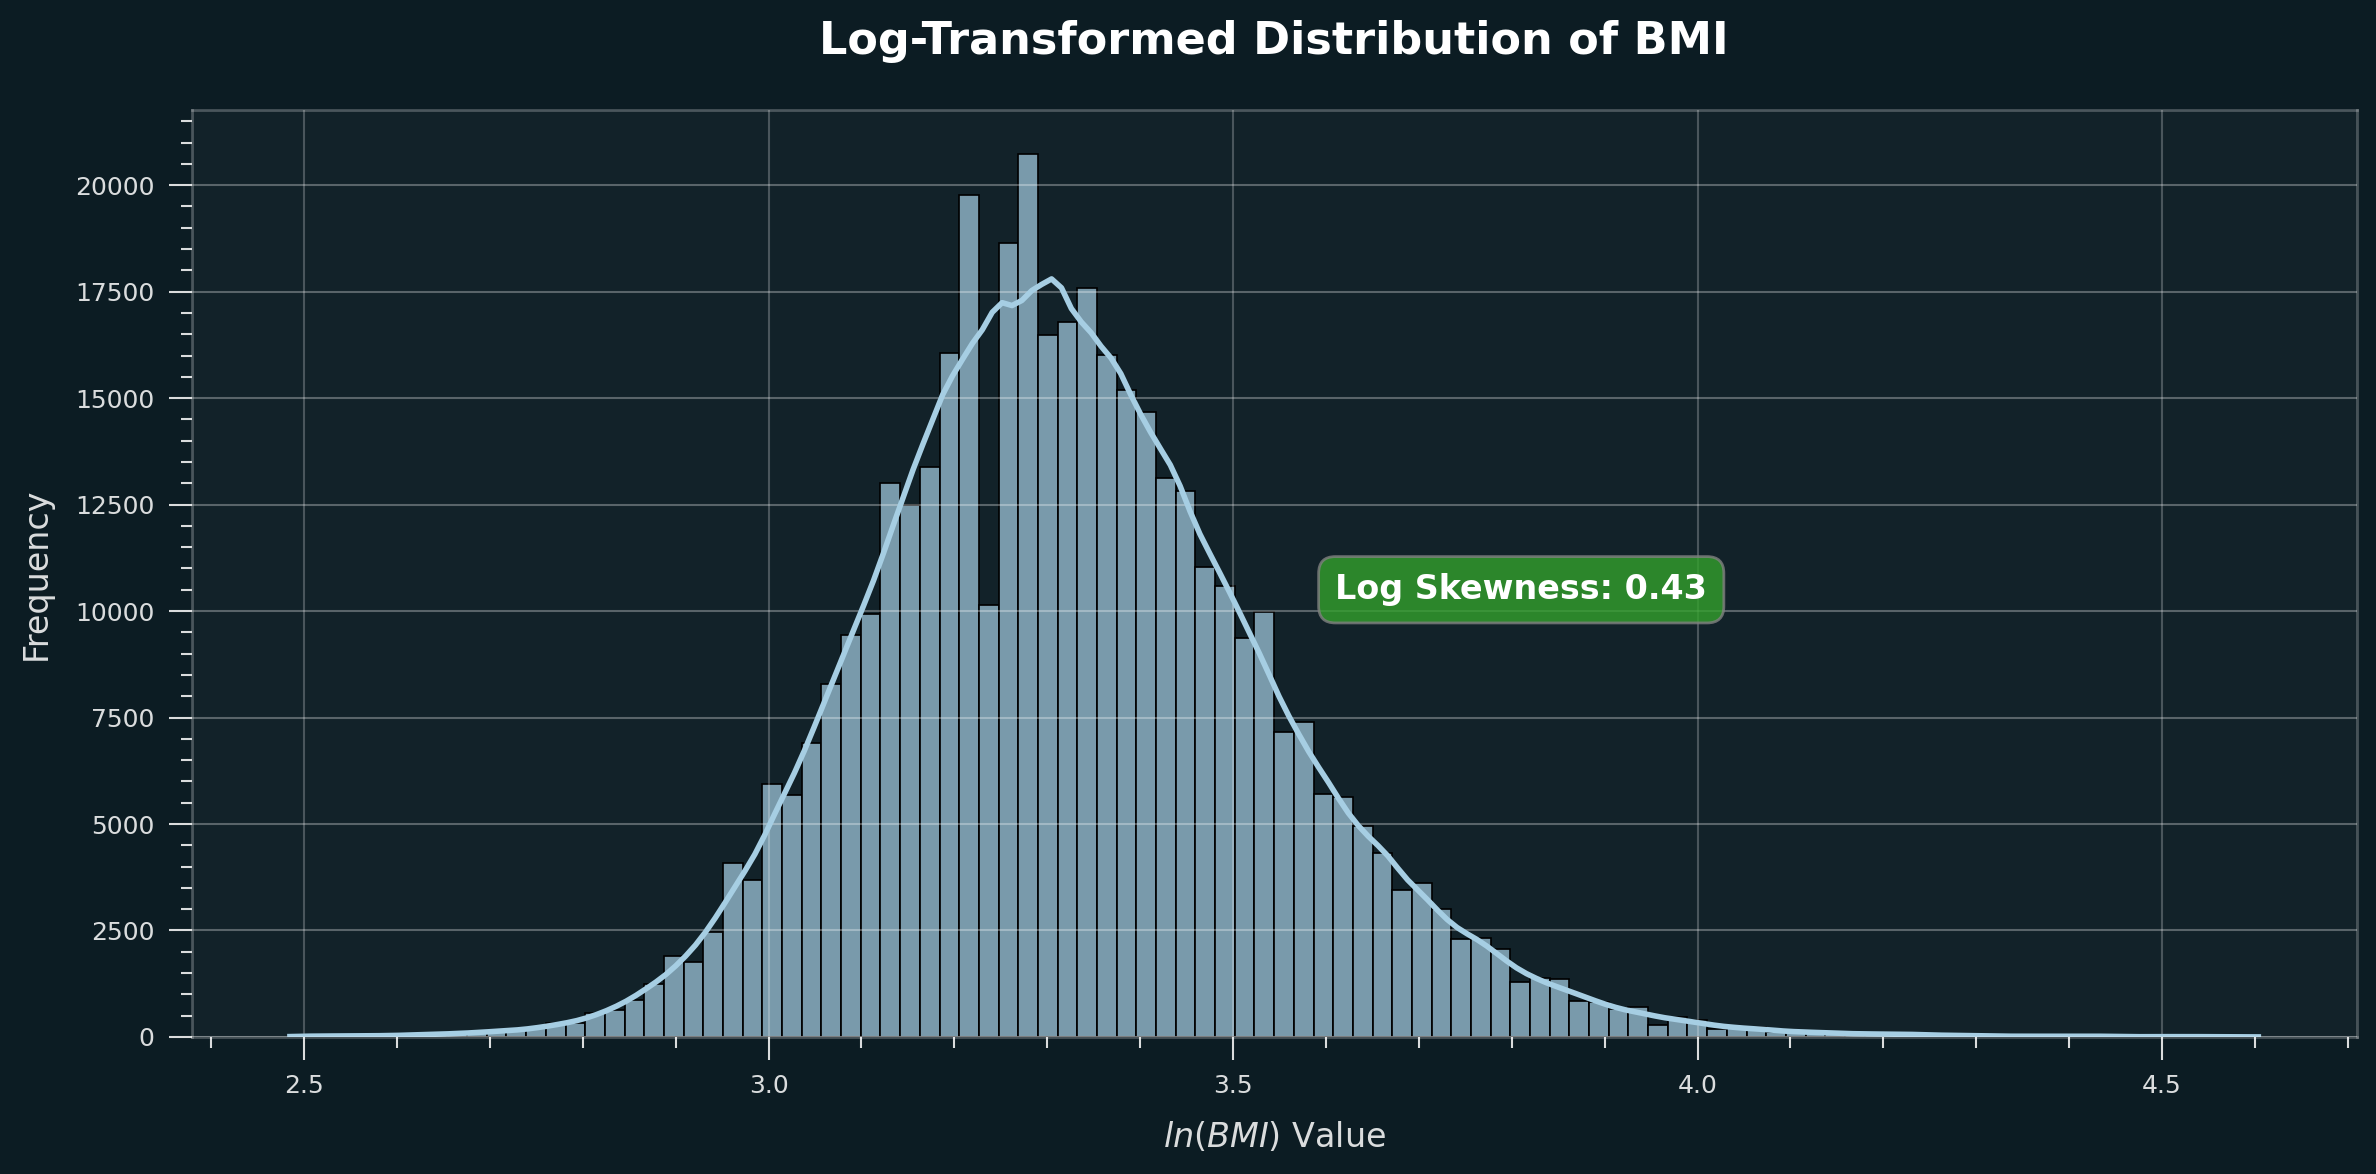

In [29]:
bmi_raw = pd.to_numeric(df_eda['_BMI5'], errors='coerce').dropna()

bmi_log = np.log(bmi_raw)

log_skew = bmi_log.skew()

plt.figure(figsize=(12, 6))

ax = sns.histplot(bmi_log, 
                 kde=True, 
                 color='C8',
                 line_kws={'color': 'red', 'lw': 2},
                 bins=100,
                 edgecolor='black',
                 alpha=0.7)

plt.text(0.7, 0.50, f'Log Skewness: {log_skew:.2f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='C1', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Log-Transformed Distribution of BMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('$ln(BMI)$ Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"./outputs/modelling/BMI_Log.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

Seems like log transform already did a decent job where the transformed skewness value already falls under 0.5, let's continue with the other 2 methods to see if they perform better than this or not. 

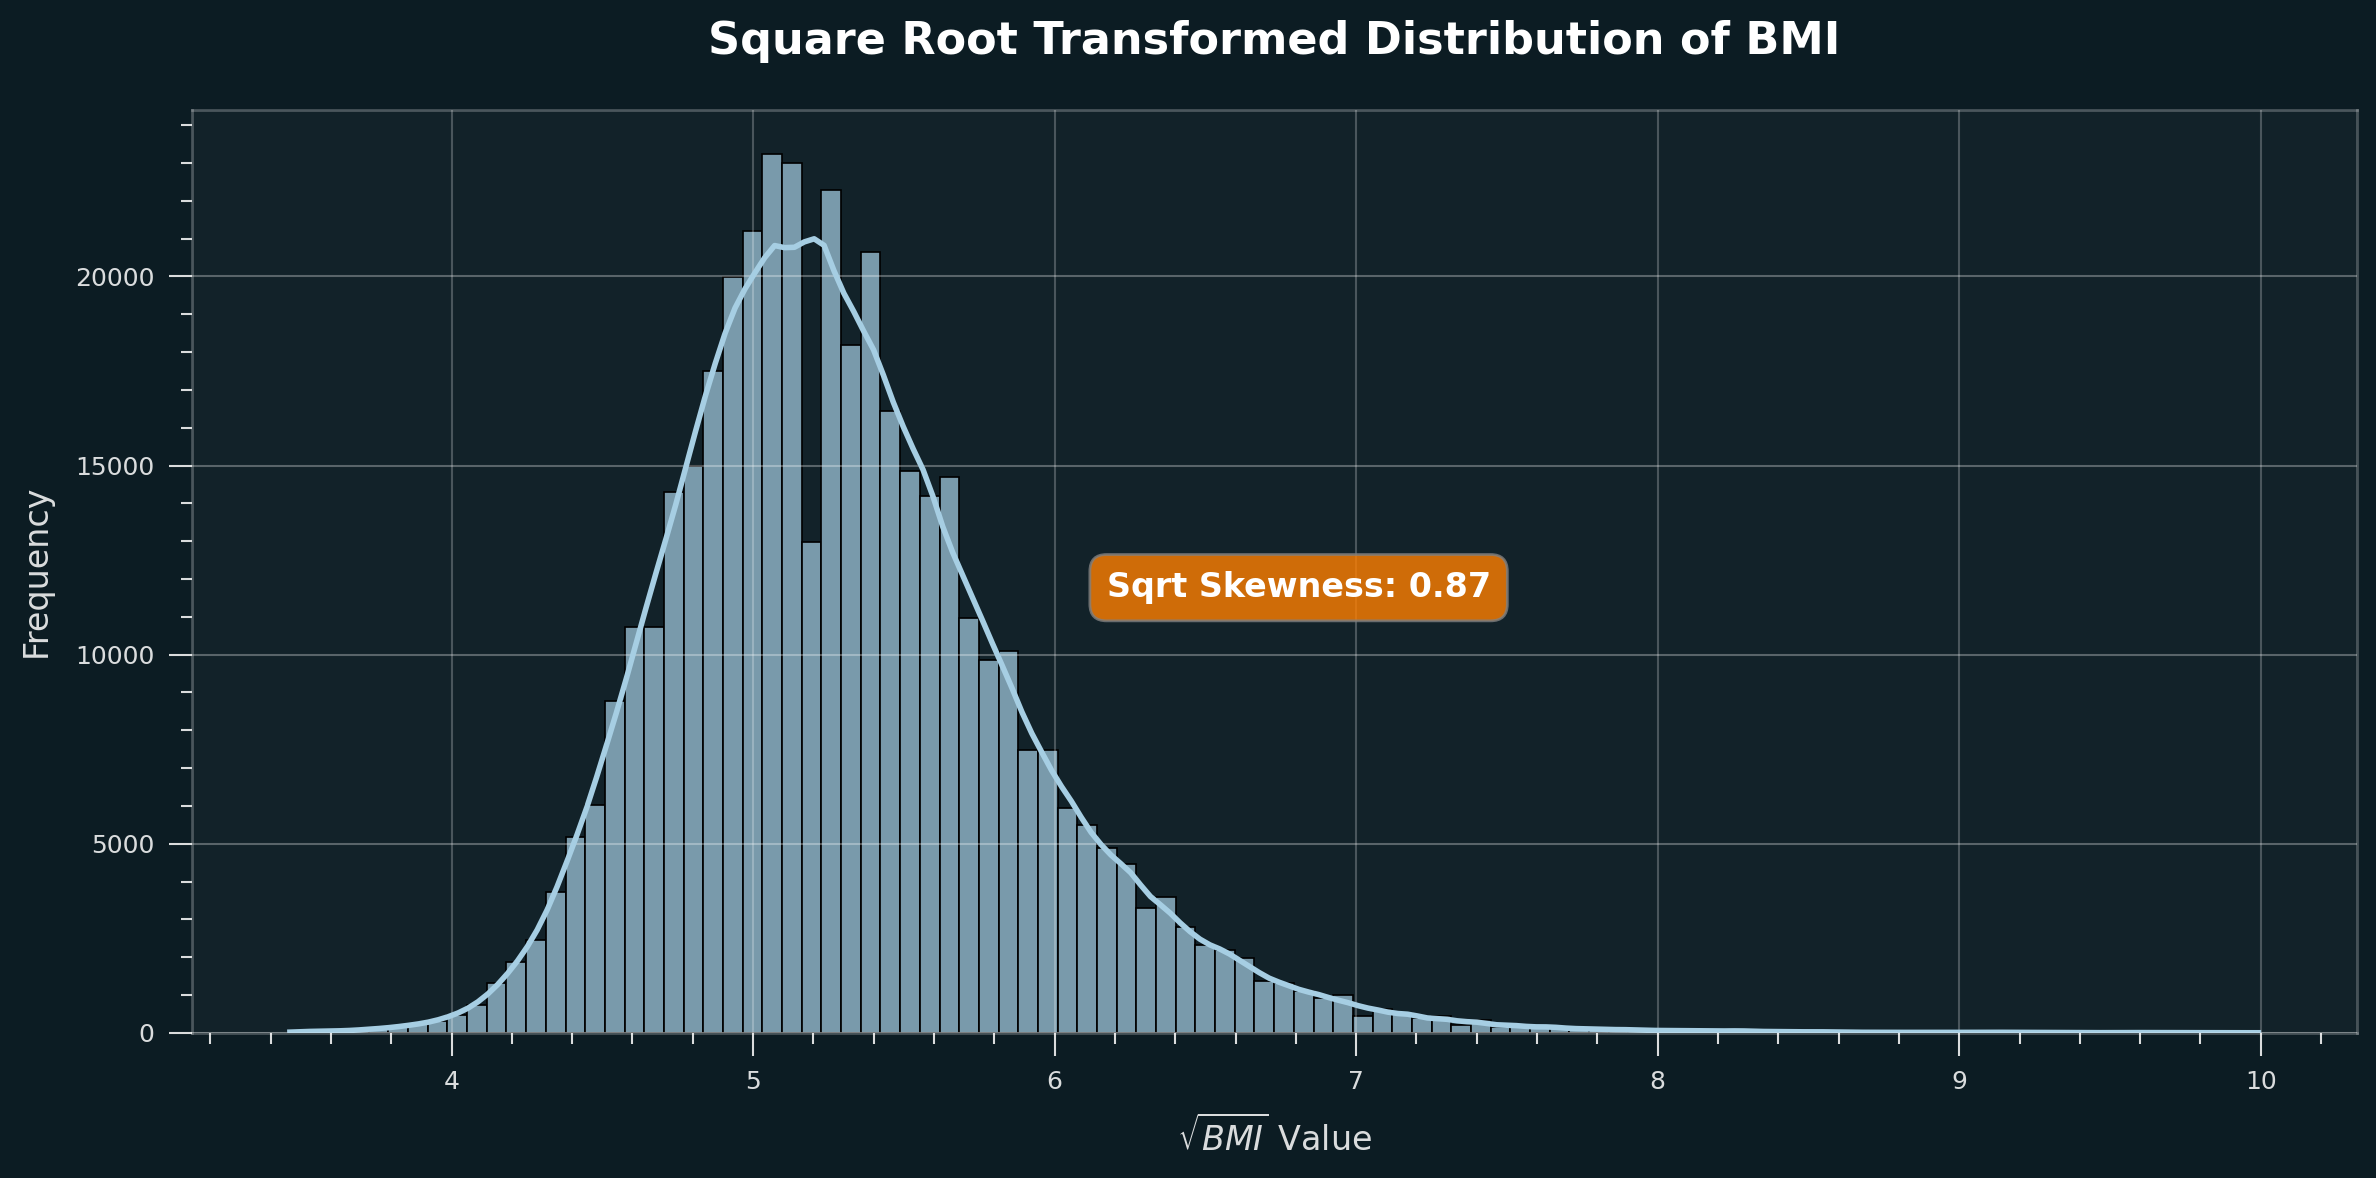

In [30]:
bmi_raw = pd.to_numeric(df_eda['_BMI5'], errors='coerce').dropna()

bmi_sqrt = np.sqrt(bmi_raw)

sqrt_skew = bmi_sqrt.skew()

plt.figure(figsize=(12, 6))

ax = sns.histplot(bmi_sqrt, 
                 kde=True, 
                 color='C8',
                 line_kws={'color': 'red', 'lw': 2},
                 bins=100,
                 edgecolor='black',
                 alpha=0.7)

plt.text(0.6, 0.50, f'Sqrt Skewness: {sqrt_skew:.2f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='C2', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Square Root Transformed Distribution of BMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(r'$\sqrt{BMI}$ Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"./outputs/modelling/BMI_sqrt.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

Square root transform did not do that well in this particular dataset. While it successfully turned the highly skewed data(skewness > 1) into moderetaly skewed data (0.5 > skewness < 1.0) log transform still performed way better by turning into an approximately symmetrical data as shown before.

In [32]:
stats

count    449514.000000
mean          4.414697
std           8.360289
min           0.000000
25%           0.000000
50%           0.000000
75%           5.000000
max          30.000000
Name: MENTHLTH, dtype: float64

In [31]:
bmi_raw = pd.to_numeric(df_eda['_BMI5'], errors='coerce').dropna()
if bmi_raw.max() > 100:
    bmi_raw = bmi_raw / 100

bmi_bc, best_lambda = stats.boxcox(bmi_raw)

bc_skew = pd.Series(bmi_bc).skew()

plt.figure(figsize=(12, 6))

ax = sns.histplot(bmi_bc, 
                 kde=True, 
                 color='C8',
                 line_kws={'color': 'red', 'lw': 2},
                 bins=70,
                 edgecolor='black',
                 alpha=0.7)

plt.text(0.95, 0.90, f'Box-Cox Skewness: {bc_skew:.4f}', 
         transform=ax.transAxes, 
         fontsize=12, 
         fontweight='bold',
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='C1', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.title('Box-Cox Transformed Distribution of BMI', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'Box-Cox Transformed Value ($\lambda = {best_lambda:.2f}$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"./outputs/modelling/BMI_boxcox.png", dpi=300, transparent=True, bbox_inches='tight',pad_inches=0.1, format='png')
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_25794/3977960638.py:28: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'Box-Cox Transformed Value ($\lambda = {best_lambda:.2f}$)', fontsize=12)


AttributeError: 'Series' object has no attribute 'boxcox'

Seems like box-cox transform is the winner with a skewness value of nearly 0, which mean the data is almost perfectly symmetrical. 

The Square Root was a bit too "gentle" to handle that long BMI tail, and while the Log transformation did a great job (getting us down to 0.42), the Box-Cox transformation absolutely crushed it.

With a final skewness of -0.01, the Box-Cox method has effectively "neutralized" the skewness, giving us a nearly perfectly symmetrical distribution. This is exactly what we want for any models that assume normality. By letting the math find the optimal λ, we've turned a messy, skewed feature into a clean, bell-shaped input. We will proceed with the Box-Cox transformed BMI for our further analysis and modeling.

## Conclusion

Well real-world data is almost always a bit of a disastrous clump of mess. When we analyzed in our three main numerical columns, **BMI**, **Children**, and **Mental Health**, they were full of the typical "messiness": weird tails, rare outliers, and a giant wall of zeros. Here’s the conclustion of how we plan clean things up based on the analysis above.

##### 1. Smoothing Out the BMI Distribution
When we first plotted **BMI**, ut had a heavy right tail with a **skewness of 1.42**, which is a classic headache in biometric data. If we left it as-is, those extreme high-BMI values would end up confusing our model’s weights, leading to biased predictions for everyone else. To fix this, we will be throwing a **Box-Cox Transformation** at it. It worked like a char, we managed to slash that skewness down to **-0.01**. Now, we’re looking at a near-perfect **Bell Curve**.


##### 2. Simplifying the "Children" Count
The **Children** column was a different kind of problem. While it’s a simple discrete count, the data gets incredibly sparse once it hit 5 or more kids. Those high-value cases are so rare that they basically act like statistical noise; trying to have the model learn a specific pattern for "9 children" versus "10 children" is a one-way ticket to **overfitting**. We decided to keep it simple and used **Ordinal Binning**. We capped the count and lumped everyone with 5 or more children into a single **"4+" category**. It makes the distribution way more balanced and treats "large families" as one meaningful group, which keeps our model from chasing ghosts in the tail of the data.


##### 3. Clearing the Mental Health "Hurdle"
Finally, we had to deal with the **Mental Health** column (our "bad days" count), and it was a mess. It had massive **Zero-Inflation**, a giant spike at zero that gave us a **skewness of 2.11**. That "wall of zeros" was basically hiding all the interesting nuances of the people who actually *were* struggling. To solve this, we took a **Hurdle Model approach**. Instead of one messy column, we split it into two: 
* **The "Hurdle" Flag:** A simple binary 0 or 1 (did they have *any* bad days?).
* **The Intensity Score:** For the people who said "yes," how many days was it? 

By isolating the people who cleared the hurdle, the skewness in our intensity column dropped to a much more manageable **0.88**. Now, the model can tackle two different questions: *"Is someone likely to be distressed?"* and *"If so, how severe is it?"* It’s a much more sophisticated way to handle the data.